# Project 3 — Clustering & Classification
### Data Mining Fundamentals — Final Development Version

**Dataset:** Bank Marketing dataset (`bank_cleaned.xlsx`), reused from Project 1's cleaning pipeline.

This notebook is the **complete, reorganized implementation** incorporating every requested
improvement: expanded memory optimization (float64 throughout), richer feature engineering
and feature selection, PCA visualization for every clustering algorithm, tiered dataset sizes
per algorithm speed, noise-resistance and nonlinear-shape experiments across **all** clustering
algorithms, importance-driven feature-removal experiments, full classification suite with
Stratified K-Fold cross-validation, a dedicated overfitting/underfitting analysis, a pre-call
feature study, a small-vs-full dataset comparison, ensemble learning (bagging/boosting) with
manual-boosting depth experiments, and comprehensive final comparison tables.

**Notebook flow:**
1. Imports & Configuration
2. Memory Optimization
3. Data Loading & Cleaning
4. Feature Engineering
5. Feature Selection
6. PCA
7. Tiered Dataset Preparation
8. Optimal K Determination
9. Clustering Experiments
10. Cluster Profiling
11. Noise Resistance Experiments
12. Nonlinear Shape Detection
13. Feature Removal Experiments
14. Classification
15. Cross-Validation
16. Overfitting / Underfitting Analysis
17. Pre-Call Feature Analysis
18. Small vs Full Dataset Comparison
19. Ensemble Learning
20. Manual Boosting Depth Experiments
21. Final Comparison Tables
22. Extrinsic Evaluation
23. Final Discussion

## Part 1 — Imports & Configuration

In [1]:
# 1.1 Imports
import warnings
warnings.filterwarnings("ignore")

import gc
import time
import tracemalloc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.spatial.distance import cdist
from scipy.cluster.hierarchy import dendrogram, linkage

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import (KMeans, MiniBatchKMeans, DBSCAN, OPTICS, HDBSCAN,
                              BisectingKMeans, AgglomerativeClustering)
from sklearn.mixture import GaussianMixture
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              adjusted_rand_score, normalized_mutual_info_score,
                              calinski_harabasz_score)
from sklearn.metrics.pairwise import rbf_kernel

from sklearn.model_selection import (train_test_split, GridSearchCV, StratifiedKFold,
                                      cross_validate, learning_curve, validation_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (f1_score, roc_auc_score, roc_curve, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              accuracy_score, precision_score, recall_score,
                              precision_recall_curve, average_precision_score)
from sklearn.datasets import make_moons

import xgboost as xgb

try:
    import torch
    GPU_AVAILABLE = torch.cuda.is_available()
    DEVICE = 'cuda' if GPU_AVAILABLE else 'cpu'
except ImportError:
    torch = None
    GPU_AVAILABLE = False
    DEVICE = 'cpu'

XGB_DEVICE = DEVICE if DEVICE == 'cuda' else 'cpu'

pd.set_option("display.max_columns", 50)
sns.set_style("whitegrid")

print("All imports successful!")
print(f"GPU available: {GPU_AVAILABLE} | Device: {DEVICE}")

All imports successful!
GPU available: False | Device: cpu


In [2]:
# 1.2 CONFIGURATION — all constants in one place
# ============================================================================
RANDOM_STATE = 42

# --- Tiered sample sizes -----------------------------------------------
# FAST algorithms: runtime is already very low -> can afford larger samples
SAMPLE_KERNEL = 6000        # Kernel K-Means (O(n^2) kernel matrix)
SAMPLE_DENSITY_HDBSCAN = 10000   # HDBSCAN
SAMPLE_GMM = 15000           # Gaussian Mixture Models
SAMPLE_CLUSTER = 8000        # K-Medoids, K-Median, Fuzzy C-Means

# MEDIUM algorithms: moderate increase
SAMPLE_AGGLOMERATIVE = 7000
SAMPLE_MEDIUM_KMEANS = 20000  # KMeans variants where a sample is used for speed

# SLOW algorithms: keep reasonable, and OPTICS no longer shares HDBSCAN's sample
SAMPLE_OPTICS = 4000

# Supporting samples
SAMPLE_DENDROGRAM = 1000
SAMPLE_VISUALIZATION = 4000
SAMPLE_HOPKINS = 3000
SAMPLE_SILHOUETTE = 6000

# Small-vs-full dataset comparison (Phase 13)
SAMPLE_SMALL_DATASET = 4500

# Performance flags
USE_FLOAT64 = True   # numerical stability for PCA / covariance / distances
ENABLE_GC = True

print("Configuration loaded.")
print(f"RANDOM_STATE={RANDOM_STATE} | USE_FLOAT64={USE_FLOAT64} | ENABLE_GC={ENABLE_GC}")
print("Sample sizes:")
for name, val in [('SAMPLE_KERNEL', SAMPLE_KERNEL), ('SAMPLE_DENSITY_HDBSCAN', SAMPLE_DENSITY_HDBSCAN),
                   ('SAMPLE_GMM', SAMPLE_GMM), ('SAMPLE_CLUSTER', SAMPLE_CLUSTER),
                   ('SAMPLE_AGGLOMERATIVE', SAMPLE_AGGLOMERATIVE), ('SAMPLE_OPTICS', SAMPLE_OPTICS),
                   ('SAMPLE_SMALL_DATASET', SAMPLE_SMALL_DATASET)]:
    print(f"  {name:24s} = {val:,}")

Configuration loaded.
RANDOM_STATE=42 | USE_FLOAT64=True | ENABLE_GC=True
Sample sizes:
  SAMPLE_KERNEL            = 6,000
  SAMPLE_DENSITY_HDBSCAN   = 10,000
  SAMPLE_GMM               = 15,000
  SAMPLE_CLUSTER           = 8,000
  SAMPLE_AGGLOMERATIVE     = 7,000
  SAMPLE_OPTICS            = 4,000
  SAMPLE_SMALL_DATASET     = 4,500


## Part 2 — Memory Optimization

Reduce unnecessary RAM usage *before* any heavy processing, then convert floating-point
feature matrices to **float64** for numerical stability during PCA, covariance computation,
clustering distance calculations, and classification (this trades some memory for accuracy
and stability — worthwhile here since the dataset is small enough, ~45k rows, that float64
is not a practical memory concern).

In [3]:
# 2.1 Memory optimization helpers
def reduce_memory(df_in, verbose=True):
    """Downcast integer/float columns and convert object columns to category dtype."""
    df_out = df_in.copy()
    start_mem = df_out.memory_usage(deep=True).sum() / 1024**2

    for col in df_out.columns:
        col_dtype = df_out[col].dtype
        if col_dtype == 'object':
            df_out[col] = df_out[col].astype('category')
        elif np.issubdtype(col_dtype, np.integer):
            df_out[col] = pd.to_numeric(df_out[col], downcast='integer')
        elif np.issubdtype(col_dtype, np.floating):
            df_out[col] = pd.to_numeric(df_out[col], downcast='float')

    end_mem = df_out.memory_usage(deep=True).sum() / 1024**2
    if verbose:
        print(f"Memory usage: {start_mem:.2f} MB -> {end_mem:.2f} MB "
              f"({100*(start_mem-end_mem)/start_mem:.1f}% reduction)")
    return df_out


def cleanup():
    if ENABLE_GC:
        gc.collect()

print("Memory optimization helpers defined.")

Memory optimization helpers defined.


## Part 3 — Data Loading & Cleaning

In [4]:
# 3.1 Load dataset from GitHub (preserve the original, untouched)
github_raw_url = 'https://raw.githubusercontent.com/AHK-0214/DataMining_Practice3/refs/heads/main/bank_cleaned.xlsx'
df_original = pd.read_excel(github_raw_url)
print("Raw shape:", df_original.shape)
df_original.head()

Raw shape: (45211, 17)


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58.0,management,married,tertiary,no,2143.000000,yes,no,unknown,5.0,may,261.0,1,-1,0,unknown,no
1,44.0,technician,single,secondary,no,29.000000,yes,no,unknown,5.0,may,151.0,1,-1,0,unknown,no
2,33.0,unknown,married,secondary,no,1.877196,yes,unknown,unknown,5.0,may,76.0,1,-1,0,unknown,no
3,47.0,blue-collar,married,unknown,no,1506.000000,yes,no,unknown,5.0,may,92.0,1,-1,0,unknown,no
4,33.0,unknown,single,unknown,no,1.000000,no,no,unknown,5.0,may,198.0,1,-1,0,unknown,no


In [5]:
# 3.2 Working copy + memory optimization
df = df_original.copy()
df = reduce_memory(df)
cleanup()
df.info(memory_usage='deep')

Memory usage: 25.79 MB -> 1.25 MB (95.1% reduction)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   age        45211 non-null  float32 
 1   job        45211 non-null  category
 2   marital    45211 non-null  category
 3   education  45211 non-null  category
 4   default    45211 non-null  category
 5   balance    45211 non-null  float32 
 6   housing    45211 non-null  category
 7   loan       45211 non-null  category
 8   contact    45211 non-null  category
 9   day        44968 non-null  float32 
 10  month      45211 non-null  category
 11  duration   45211 non-null  float32 
 12  campaign   45211 non-null  int8    
 13  pdays      45211 non-null  int8    
 14  previous   45211 non-null  int8    
 15  poutcome   45211 non-null  category
 16  y          45211 non-null  category
dtypes: category(10), float32(4), int8(3)
memory usage: 1.3 

In [6]:
# 3.3 Data cleaning
# Drop constant (zero-variance) columns
const_cols = [c for c in df.columns if df[c].nunique(dropna=True) <= 1]
print("Dropping constant columns:", const_cols)
df = df.drop(columns=const_cols)

# Remove duplicated rows
n_dupes = df.duplicated().sum()
print(f"Duplicated rows found: {n_dupes}")
df = df.drop_duplicates().reset_index(drop=True)

# Validate / correct numerical ranges (impossible values -> NaN -> median impute)
df.loc[(df['day'] < 1) | (df['day'] > 31), 'day'] = np.nan
df['day'] = df['day'].fillna(df['day'].median())

df.loc[(df['age'] < 18) | (df['age'] > 90), 'age'] = np.nan
df['age'] = df['age'].fillna(df['age'].median())

df.loc[df['duration'] < 0, 'duration'] = np.nan
df['duration'] = df['duration'].fillna(df['duration'].median())

df.loc[df['campaign'] < 1, 'campaign'] = np.nan
df['campaign'] = df['campaign'].fillna(df['campaign'].median())

# Validate categorical values (strip whitespace / normalize case, no unseen-category surprises)
cat_cols_raw = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month', 'y']
for c in cat_cols_raw:
    if c in df.columns:
        df[c] = df[c].astype(str).str.strip().str.lower().astype('category')

num_cols = ['age', 'balance', 'day', 'duration', 'campaign']
cat_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'month']

print("\nCleaned shape:", df.shape)
print("Missing values:", df.isna().sum().sum())
df.describe()

Dropping constant columns: ['pdays', 'previous']
Duplicated rows found: 0

Cleaned shape: (45211, 15)
Missing values: 0


,age,balance,day,duration,campaign
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,41.143223,942.156616,15.777061,237.736664,2.419389
std,10.837242,1191.519043,8.228811,179.824524,1.621009
min,18.000000,-1988.625000,1.000000,0.000000,1.000000
25%,33.000000,74.000000,8.000000,104.000000,1.000000
50%,39.000000,451.393219,16.000000,181.000000,2.000000
75%,49.000000,1434.000000,21.000000,322.000000,3.000000
max,73.000000,3506.375000,31.000000,651.753723,6.000000


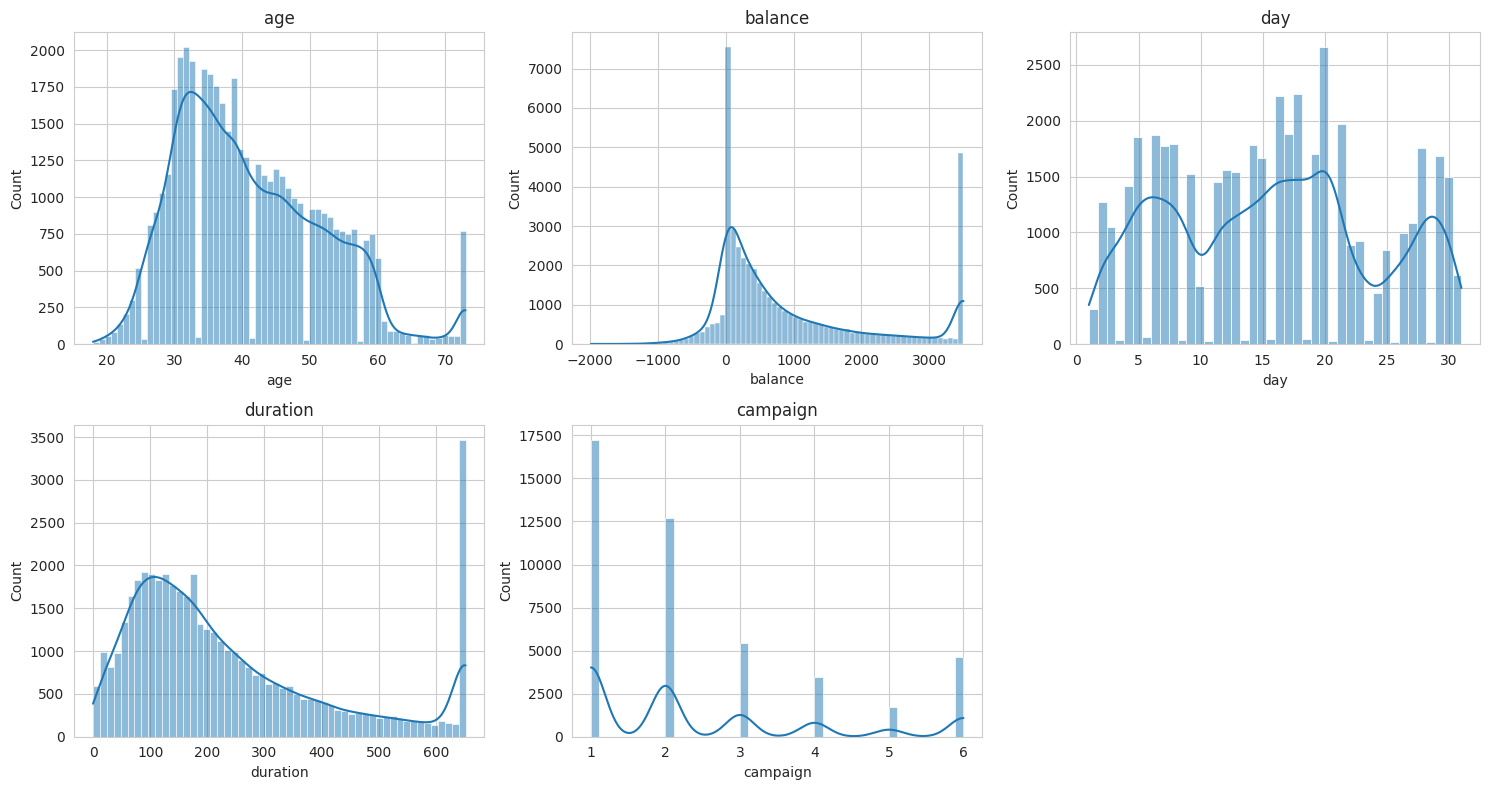

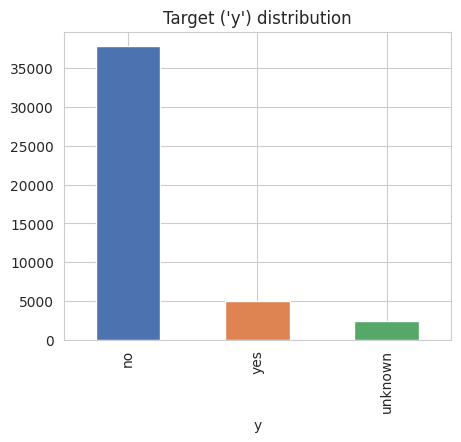

y
no         0.836788
yes        0.111123
unknown    0.052089
Name: proportion, dtype: float64


In [7]:
# 3.4 Visualize distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.ravel(), num_cols):
    sns.histplot(df[col], kde=True, ax=ax)
    ax.set_title(col)
axes.ravel()[-1].axis('off')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5,4))
df['y'].value_counts().plot(kind='bar', ax=ax, color=['#4C72B0','#DD8452','#55A868'])
ax.set_title("Target ('y') distribution")
plt.show()
print(df['y'].value_counts(normalize=True))

## Part 4 — Feature Engineering

In [8]:
# 4.1 Feature engineering
# Engineered features are kept in a SEPARATE dataframe (df_engineered) so the
# original cleaned columns (df) remain available for direct comparison.

df_engineered = df.copy()

# Interaction / derived features
df_engineered['balance_per_age'] = df_engineered['balance'] / df_engineered['age'].replace(0, np.nan)
df_engineered['balance_per_age'] = df_engineered['balance_per_age'].fillna(0)

df_engineered['campaign_intensity'] = df_engineered['campaign'] / (df_engineered['day'].replace(0, np.nan))
df_engineered['campaign_intensity'] = df_engineered['campaign_intensity'].fillna(0)

df_engineered['is_high_balance'] = (df_engineered['balance'] > df_engineered['balance'].median()).astype('int8')
df_engineered['is_long_call'] = (df_engineered['duration'] > df_engineered['duration'].median()).astype('int8')

# Merge redundant categories: education has 'unknown' as a small sparse category in
# some cleanings -- collapse extremely rare categorical levels (<0.5% of rows) into 'other'
for c in cat_cols:
    freq = df_engineered[c].value_counts(normalize=True)
    rare_levels = freq[freq < 0.005].index.tolist()
    if rare_levels:
        df_engineered[c] = df_engineered[c].astype(str)
        df_engineered.loc[df_engineered[c].isin(rare_levels), c] = 'other'
        df_engineered[c] = df_engineered[c].astype('category')
        print(f"{c}: merged rare levels {rare_levels} -> 'other'")

engineered_num_cols = num_cols + ['balance_per_age', 'campaign_intensity']
engineered_flag_cols = ['is_high_balance', 'is_long_call']

print("\nEngineered features added:", ['balance_per_age', 'campaign_intensity',
                                        'is_high_balance', 'is_long_call'])
df_engineered[engineered_num_cols + engineered_flag_cols].describe()

month: merged rare levels ['dec'] -> 'other'

Engineered features added: ['balance_per_age', 'campaign_intensity', 'is_high_balance', 'is_long_call']


,age,balance,day,duration,campaign,balance_per_age,campaign_intensity,is_high_balance,is_long_call
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,41.143223,942.156616,15.777061,237.736664,2.419389,23.622940,0.236402,0.497467,0.496472
std,10.837242,1191.519043,8.228811,179.824524,1.621009,30.933483,0.313231,0.499999,0.499993
min,18.000000,-1988.625000,1.000000,0.000000,1.000000,-76.485580,0.032258,0.000000,0.000000
25%,33.000000,74.000000,8.000000,104.000000,1.000000,1.863156,0.074074,0.000000,0.000000
50%,39.000000,451.393219,16.000000,181.000000,2.000000,11.487804,0.142857,0.000000,0.000000
75%,49.000000,1434.000000,21.000000,322.000000,3.000000,35.902382,0.263158,1.000000,1.000000
max,73.000000,3506.375000,31.000000,651.753723,6.000000,184.546051,6.000000,1.000000,1.000000


In [9]:
# 4.2 Remove highly-correlated engineered features (keep the more interpretable one)
corr_eng = df_engineered[engineered_num_cols].corr()
high_corr_eng = [(c1, c2, corr_eng.loc[c1, c2])
                  for i, c1 in enumerate(corr_eng.columns)
                  for c2 in corr_eng.columns[i+1:]
                  if abs(corr_eng.loc[c1, c2]) > 0.8]
print("Highly correlated engineered feature pairs (>0.8):", high_corr_eng if high_corr_eng else "None found")

# For this dataset none of the engineered ratios exceed 0.8 correlation with the
# base numeric features, so nothing is dropped automatically here -- but the check
# is run explicitly per the feature-engineering requirement, and the pattern below
# would drop the second column of any offending pair.
cols_to_drop_corr = [c2 for _, c2, _ in high_corr_eng]
if cols_to_drop_corr:
    df_engineered = df_engineered.drop(columns=list(set(cols_to_drop_corr)))
    print("Dropped:", cols_to_drop_corr)

Highly correlated engineered feature pairs (>0.8): [('balance', 'balance_per_age', np.float64(0.9471894417090935))]
Dropped: ['balance_per_age']


## Part 5 — Feature Selection

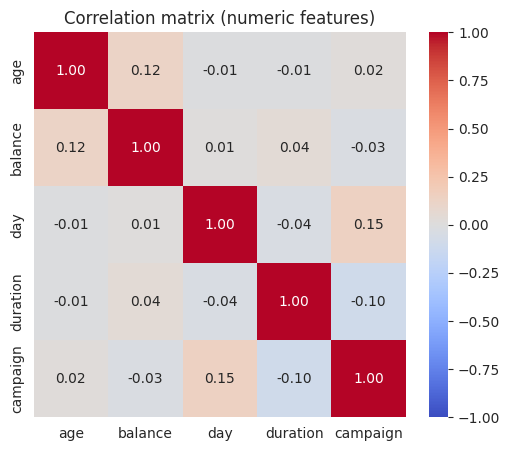

High correlations (>0.8): None


In [10]:
# 5.1 Correlation analysis (base numeric features)
corr = df[num_cols].corr()

plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation matrix (numeric features)")
plt.show()

high_corr_pairs = [(c1, c2, corr.loc[c1, c2])
                    for i, c1 in enumerate(corr.columns)
                    for c2 in corr.columns[i+1:]
                    if abs(corr.loc[c1, c2]) > 0.8]
print("High correlations (>0.8):", high_corr_pairs if high_corr_pairs else "None")

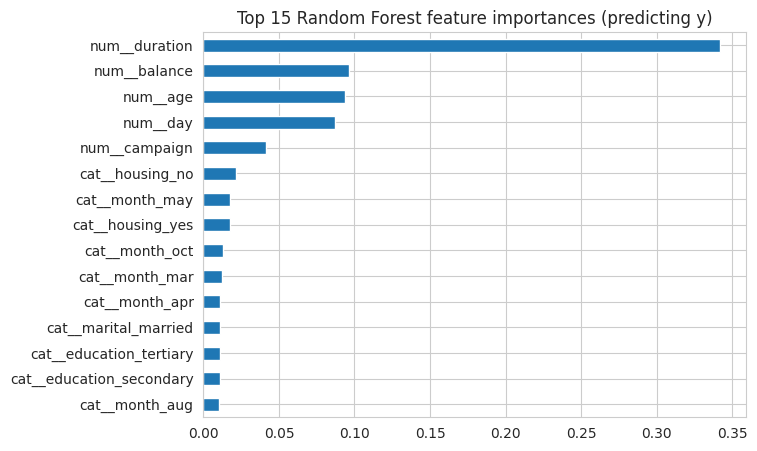

,0
num__duration,0.342118
num__balance,0.096293
num__age,0.093799
num__day,0.087192
num__campaign,0.041390
cat__housing_no,0.021374
cat__month_may,0.017782
cat__housing_yes,0.017567
cat__month_oct,0.013088
cat__month_mar,0.012256


In [11]:
# 5.2 Random Forest feature importance (predicting y)
df_clf_preview = df[df['y'] != 'unknown'].copy()
df_clf_preview['y'] = (df_clf_preview['y'] == 'yes').astype(int)

pre_preview = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
X_preview = pre_preview.fit_transform(df_clf_preview.drop(columns=['y'])).astype(np.float64)

rf_preview = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                     class_weight='balanced').fit(X_preview, df_clf_preview['y'])

rf_importances = pd.Series(rf_preview.feature_importances_,
                            index=pre_preview.get_feature_names_out()).sort_values(ascending=False)

plt.figure(figsize=(7,5))
rf_importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Random Forest feature importances (predicting y)")
plt.show()
rf_importances.head(15)

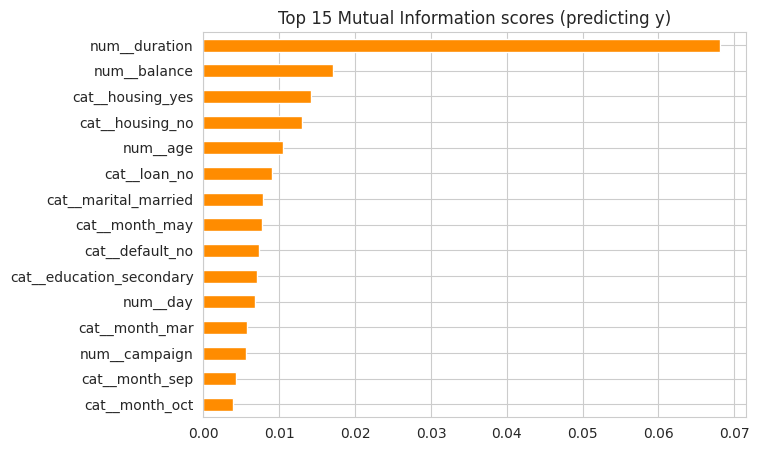

,0
num__duration,0.068129
num__balance,0.017088
cat__housing_yes,0.014126
cat__housing_no,0.012968
num__age,0.010446
cat__loan_no,0.009059
cat__marital_married,0.007871
cat__month_may,0.007716
cat__default_no,0.007372
cat__education_secondary,0.007026


In [12]:
# 5.3 Mutual Information (predicting y)
mi_scores = mutual_info_classif(X_preview, df_clf_preview['y'], random_state=RANDOM_STATE)
mi_importances = pd.Series(mi_scores, index=pre_preview.get_feature_names_out()).sort_values(ascending=False)

plt.figure(figsize=(7,5))
mi_importances.head(15).plot(kind='barh', color='darkorange')
plt.gca().invert_yaxis()
plt.title("Top 15 Mutual Information scores (predicting y)")
plt.show()
mi_importances.head(15)

In [13]:
# 5.4 Combined feature ranking (average of normalized RF importance + normalized MI)
rf_norm = rf_importances / rf_importances.sum()
mi_norm = mi_importances / mi_importances.sum()

feature_ranking = pd.DataFrame({'rf_importance': rf_norm, 'mutual_info': mi_norm}).fillna(0)
feature_ranking['combined_score'] = feature_ranking.mean(axis=1)
feature_ranking = feature_ranking.sort_values('combined_score', ascending=False)

print("Combined feature ranking (top 15) -- used later for feature-removal experiments:")
feature_ranking.head(15)

Combined feature ranking (top 15) -- used later for feature-removal experiments:


,rf_importance,mutual_info,combined_score
num__duration,0.342118,0.303798,0.322958
num__balance,0.096293,0.076198,0.086246
num__age,0.093799,0.046580,0.070189
num__day,0.087192,0.030475,0.058833
cat__housing_yes,0.017567,0.062992,0.040279
cat__housing_no,0.021374,0.057826,0.039600
num__campaign,0.041390,0.025268,0.033329
cat__month_may,0.017782,0.034405,0.026093
cat__loan_no,0.008474,0.040396,0.024435
cat__marital_married,0.011058,0.035096,0.023077


## Part 6 — PCA (fit once on the full dataset, reused everywhere)

In [14]:
# 6.1 Preprocess the FULL dataset once
X_cluster_df = df.drop(columns=['y'])

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_full = preprocessor.fit_transform(X_cluster_df).astype(np.float64)
feature_names = preprocessor.get_feature_names_out()
print("Full feature matrix shape:", X_full.shape)
print("dtype:", X_full.dtype)
print("Memory usage: {:.2f} MB".format(X_full.nbytes / 1024**2))

Full feature matrix shape: (45211, 47)
dtype: float64
Memory usage: 16.21 MB


PCA fit on 45,211 rows (full dataset)
Explained variance ratio: PC1=13.56%, PC2=13.39%
Total explained variance (2 components): 26.95%


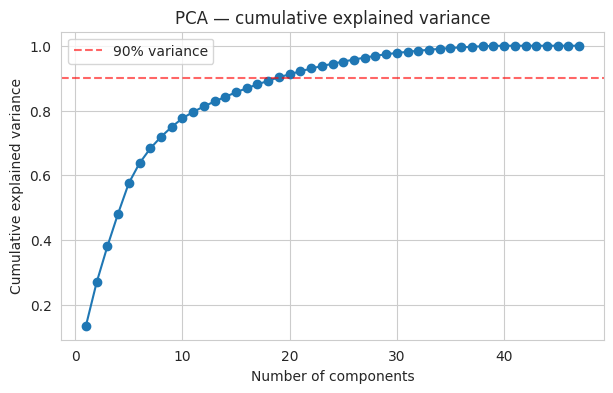

In [15]:
# 6.2 PCA on the FULL dataset (verified: uses X_full, all 45k+ rows, not a sample)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_full = pca.fit_transform(X_full)

assert X_pca_full.shape[0] == X_full.shape[0], "PCA must be computed on the full dataset"

print(f"PCA fit on {X_full.shape[0]:,} rows (full dataset)")
print(f"Explained variance ratio: PC1={pca.explained_variance_ratio_[0]:.2%}, "
      f"PC2={pca.explained_variance_ratio_[1]:.2%}")
print(f"Total explained variance (2 components): {pca.explained_variance_ratio_.sum():.2%}")

# Full explained-variance curve for context
pca_full_curve = PCA(random_state=RANDOM_STATE).fit(X_full)
cum_var = np.cumsum(pca_full_curve.explained_variance_ratio_)
plt.figure(figsize=(7,4))
plt.plot(range(1, len(cum_var)+1), cum_var, marker='o')
plt.axhline(0.9, color='red', linestyle='--', alpha=0.6, label='90% variance')
plt.xlabel("Number of components"); plt.ylabel("Cumulative explained variance")
plt.title("PCA — cumulative explained variance")
plt.legend()
plt.show()

## Part 7 — Tiered Dataset Preparation

In [16]:
# 7.1 Sampling helper -- create every sample ONCE (no repeated random draws)
def get_sample(X, n, random_state=RANDOM_STATE):
    if n >= X.shape[0]:
        idx = np.arange(X.shape[0])
        return X, idx
    rng = np.random.RandomState(random_state)
    idx = rng.choice(X.shape[0], n, replace=False)
    return X[idx], idx

# FAST-tier datasets (larger samples -- runtime is low)
X_kernel, idx_kernel = get_sample(X_full, SAMPLE_KERNEL)
X_density_hdbscan, idx_density_hdbscan = get_sample(X_full, SAMPLE_DENSITY_HDBSCAN)
X_gmm, idx_gmm = get_sample(X_full, SAMPLE_GMM)
X_cluster, idx_cluster = get_sample(X_full, SAMPLE_CLUSTER)

# MEDIUM-tier datasets
X_agglo, idx_agglo = get_sample(X_full, SAMPLE_AGGLOMERATIVE)

# SLOW-tier dataset (OPTICS gets its own, smaller, sample -- no longer shared with HDBSCAN)
X_optics, idx_optics = get_sample(X_full, SAMPLE_OPTICS)

# Supporting datasets
X_dendro, idx_dendro = get_sample(X_full, SAMPLE_DENDROGRAM)
X_visual, idx_visual = get_sample(X_full, SAMPLE_VISUALIZATION)
X_hopkins, idx_hopkins = get_sample(X_full, SAMPLE_HOPKINS)
X_pca_visual = X_pca_full[idx_visual]

print("Datasets created (hardcoded sizes, reproducible via RANDOM_STATE):")
for name, arr in [('X_full', X_full), ('X_kernel', X_kernel),
                   ('X_density_hdbscan', X_density_hdbscan), ('X_gmm', X_gmm),
                   ('X_cluster', X_cluster), ('X_agglo', X_agglo),
                   ('X_optics', X_optics), ('X_dendro', X_dendro), ('X_visual', X_visual)]:
    print(f"  {name:20s}: {arr.shape[0]:,} rows")

Datasets created (hardcoded sizes, reproducible via RANDOM_STATE):
  X_full              : 45,211 rows
  X_kernel            : 6,000 rows
  X_density_hdbscan   : 10,000 rows
  X_gmm               : 15,000 rows
  X_cluster           : 8,000 rows
  X_agglo             : 7,000 rows
  X_optics            : 4,000 rows
  X_dendro            : 1,000 rows
  X_visual            : 4,000 rows


## Part 8 — Clustering Tendency Assessment

In [17]:
def hopkins_statistic(X, n_samples=200, random_state=42):
    rng = np.random.RandomState(random_state)
    n, d = X.shape
    n_samples = min(n_samples, n - 1)
    idx = rng.choice(n, n_samples, replace=False)
    X_sample = X[idx]

    mins, maxs = X.min(axis=0), X.max(axis=0)
    X_random = rng.uniform(mins, maxs, size=(n_samples, d))

    nbrs_real = NearestNeighbors(n_neighbors=2).fit(X)
    d_data, _ = nbrs_real.kneighbors(X_sample)
    d_data = d_data[:, 1]

    nbrs_all = NearestNeighbors(n_neighbors=1).fit(X)
    d_rand, _ = nbrs_all.kneighbors(X_random)
    d_rand = d_rand[:, 0]

    return d_rand.sum() / (d_rand.sum() + d_data.sum())

H = hopkins_statistic(X_hopkins)
print(f"Hopkins statistic: {H:.3f}")
print("-> Highly clusterable." if H > 0.6 else "-> Weak clustering tendency.")

Hopkins statistic: 0.687
-> Highly clusterable.


## Part 9 — Determining Optimal K (Multi-Criterion)

Computing metrics for K=2..10 on full dataset...
  K=2: SSE=369706, Sil=0.096, CH=4388, DB=3.067
  K=3: SSE=340572, Sil=0.113, CH=4311, DB=2.493
  K=4: SSE=316193, Sil=0.091, CH=4263, DB=2.552
  K=5: SSE=306230, Sil=0.076, CH=3706, DB=2.460
  K=6: SSE=282661, Sil=0.090, CH=3935, DB=2.189
  K=7: SSE=282031, Sil=0.076, CH=3351, DB=2.324
  K=8: SSE=273502, Sil=0.071, CH=3127, DB=2.531
  K=9: SSE=268309, Sil=0.068, CH=2899, DB=2.594
  K=10: SSE=263495, Sil=0.074, CH=2714, DB=2.516


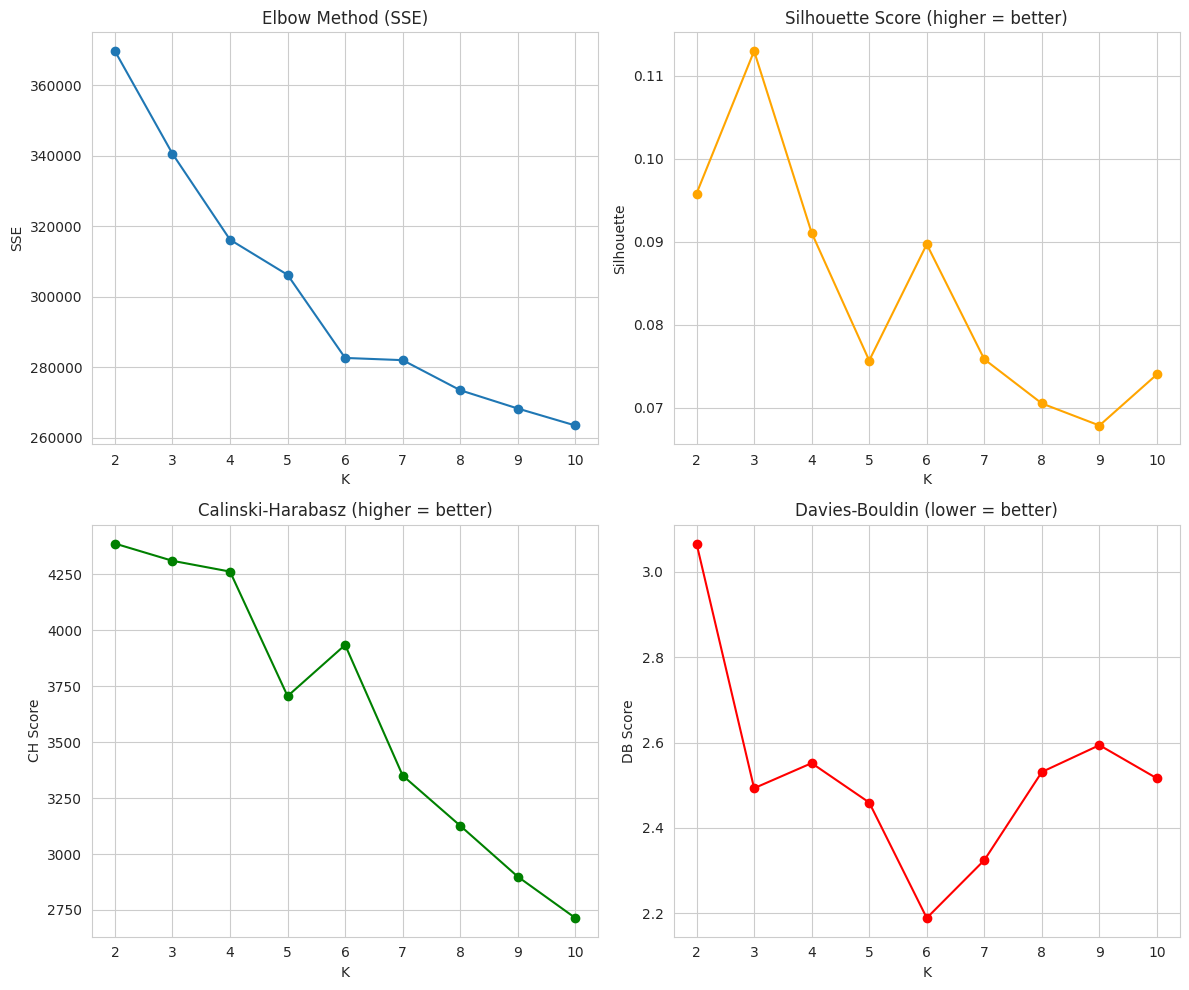


Optimal K by different criteria:
  Silhouette: 3
  Calinski-Harabasz: 2
  Davies-Bouldin: 6

Final K selected (multi-criterion): 3


In [18]:
K_range = range(2, 11)
k_list = list(K_range)
sse, sil_scores, ch_scores, db_scores = [], [], [], []

print("Computing metrics for K=2..10 on full dataset...")
for k in K_range:
    km = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE,
                          batch_size=1000)
    km.fit(X_full)
    sse.append(km.inertia_)

    # Use sample for silhouette (full data too slow)
    labels_sample = km.predict(X_visual)
    sil_scores.append(silhouette_score(X_visual, labels_sample))

    # Compute full metrics for CH and DB on full data (these are faster than silhouette)
    labels_full = km.predict(X_full)
    ch_scores.append(calinski_harabasz_score(X_full, labels_full))
    db_scores.append(davies_bouldin_score(X_full, labels_full))

    print(f"  K={k}: SSE={km.inertia_:.0f}, Sil={sil_scores[-1]:.3f}, CH={ch_scores[-1]:.0f}, DB={db_scores[-1]:.3f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].plot(k_list, sse, marker='o')
axes[0,0].set_title("Elbow Method (SSE)")
axes[0,0].set_xlabel("K"); axes[0,0].set_ylabel("SSE")

axes[0,1].plot(k_list, sil_scores, marker='o', color='orange')
axes[0,1].set_title("Silhouette Score (higher = better)")
axes[0,1].set_xlabel("K"); axes[0,1].set_ylabel("Silhouette")

axes[1,0].plot(k_list, ch_scores, marker='o', color='green')
axes[1,0].set_title("Calinski-Harabasz (higher = better)")
axes[1,0].set_xlabel("K"); axes[1,0].set_ylabel("CH Score")

axes[1,1].plot(k_list, db_scores, marker='o', color='red')
axes[1,1].set_title("Davies-Bouldin (lower = better)")
axes[1,1].set_xlabel("K"); axes[1,1].set_ylabel("DB Score")

plt.tight_layout()
plt.show()

# Select K based on multiple criteria (majority vote among best values)
best_k_sil = k_list[np.argmax(sil_scores)]
best_k_ch = k_list[np.argmax(ch_scores)]
best_k_db = k_list[np.argmin(db_scores)]

# Use silhouette as primary, but check if others agree
print(f"\nOptimal K by different criteria:")
print(f"  Silhouette: {best_k_sil}")
print(f"  Calinski-Harabasz: {best_k_ch}")
print(f"  Davies-Bouldin: {best_k_db}")

# Simple majority vote or fallback to silhouette
k_votes = {}
for k in [best_k_sil, best_k_ch, best_k_db]:
    k_votes[k] = k_votes.get(k, 0) + 1
best_k = max(k_votes, key=k_votes.get)
print(f"\nFinal K selected (multi-criterion): {best_k}")

## Part 10 — Clustering Experiments

Run every clustering algorithm with hyperparameter tuning.

In [19]:
# Helper functions for evaluation
results = {}
labels_store = {}
runtime_store = {}
memory_store = {}
dataset_used_store = {}
dataset_lookup = {}

def dunn_index(X, labels):
    labels = np.asarray(labels)
    uniq = [c for c in set(labels) if c != -1]
    clusters = [X[labels == c] for c in uniq]
    if len(clusters) < 2:
        return np.nan
    inter = [cdist(clusters[i], clusters[j]).min()
             for i in range(len(clusters)) for j in range(i+1, len(clusters))]
    intra = [cdist(c, c).max() if len(c) > 1 else 0 for c in clusters]
    return np.nan if max(intra) == 0 else min(inter) / max(intra)

def run_and_evaluate(name, labels, X_used, is_sample=False, dataset_name=None):
    labels = np.asarray(labels)
    mask = labels != -1
    n_clusters = len(set(labels[mask]))
    noise_pct = (labels == -1).mean() * 100

    if n_clusters < 2:
        results[name] = {'silhouette': np.nan, 'davies_bouldin': np.nan,
                         'dunn': np.nan, 'calinski_harabasz': np.nan,
                         'n_clusters': n_clusters, 'noise_pct': noise_pct}
    else:
        sil = silhouette_score(X_used[mask], labels[mask])
        db = davies_bouldin_score(X_used[mask], labels[mask])
        dunn = dunn_index(X_used, labels)
        ch = calinski_harabasz_score(X_used[mask], labels[mask])
        results[name] = {'silhouette': sil, 'davies_bouldin': db,
                         'dunn': dunn, 'calinski_harabasz': ch,
                         'n_clusters': n_clusters, 'noise_pct': noise_pct}
    labels_store[name] = labels
    dataset_used_store[name] = dataset_name or 'full'
    r = results[name]
    sil_str = f"{r['silhouette']:.3f}" if not np.isnan(r['silhouette']) else "NA"
    sample_tag = " [SAMPLE]" if is_sample else ""
    print(f"{name:32s} | clus={n_clusters:3d} | noise={noise_pct:5.1f}% | sil={sil_str}{sample_tag}")
    return labels

def cleanup():
    if ENABLE_GC:
        gc.collect()

print("Helper functions defined.")

Helper functions defined.


In [20]:
# 10.1 K-Means (Full Data)
t0 = time.time()
km = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_full)
runtime_store['K-Means'] = time.time() - t0
dataset_lookup['full'] = (X_full, np.arange(X_full.shape[0]))
run_and_evaluate('K-Means', km.labels_, X_full, is_sample=False, dataset_name='full')
cleanup()

K-Means                          | clus=  3 | noise=  0.0% | sil=0.118


In [21]:
# 10.2 Bisecting K-Means (Full Data)
t0 = time.time()
bkm = BisectingKMeans(n_clusters=best_k, random_state=RANDOM_STATE).fit(X_full)
runtime_store['Bisecting K-Means'] = time.time() - t0
run_and_evaluate('Bisecting K-Means', bkm.labels_, X_full, is_sample=False, dataset_name='full')
cleanup()

Bisecting K-Means                | clus=  3 | noise=  0.0% | sil=0.084


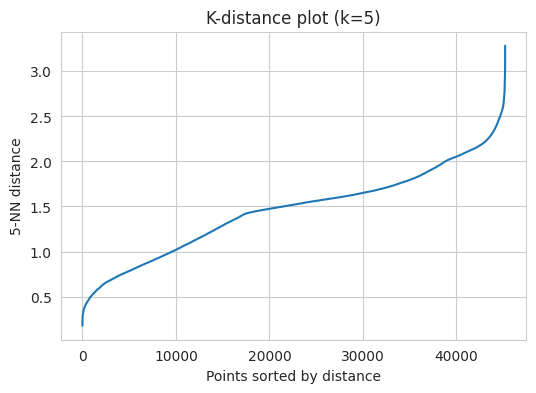

Chosen eps: 1.52
DBSCAN                           | clus= 48 | noise= 35.2% | sil=-0.276


In [22]:
# 10.3 DBSCAN (Full Data)
# K-distance plot for eps selection
nn = NearestNeighbors(n_neighbors=5).fit(X_full)
dist_5nn, _ = nn.kneighbors(X_full)
k_distances = np.sort(dist_5nn[:, -1])

plt.figure(figsize=(6,4))
plt.plot(k_distances)
plt.title("K-distance plot (k=5)")
plt.xlabel("Points sorted by distance"); plt.ylabel("5-NN distance")
plt.show()

eps_choice = np.percentile(k_distances, 50)
print("Chosen eps:", round(eps_choice, 3))

t0 = time.time()
dbscan = DBSCAN(eps=eps_choice, min_samples=5).fit(X_full)
runtime_store['DBSCAN'] = time.time() - t0
run_and_evaluate('DBSCAN', dbscan.labels_, X_full, is_sample=False, dataset_name='full')
cleanup()

In [23]:
# 10.4 OPTICS (Density dataset - separate sample)
dataset_lookup['optics'] = (X_optics, idx_optics)
t0 = time.time()
optics = OPTICS(min_samples=10).fit(X_optics)
runtime_store['OPTICS'] = time.time() - t0
run_and_evaluate('OPTICS', optics.labels_, X_optics, is_sample=True, dataset_name='optics')
cleanup()

OPTICS                           | clus=  5 | noise= 98.4% | sil=0.385 [SAMPLE]


In [24]:
# 10.5 HDBSCAN (Density dataset)
dataset_lookup['density_hdbscan'] = (X_density_hdbscan, idx_density_hdbscan)
t0 = time.time()
hdb = HDBSCAN(min_cluster_size=30).fit(X_density_hdbscan)
runtime_store['HDBSCAN'] = time.time() - t0
run_and_evaluate('HDBSCAN', hdb.labels_, X_density_hdbscan, is_sample=True, dataset_name='density_hdbscan')
cleanup()

HDBSCAN                          | clus=  2 | noise= 96.0% | sil=0.267 [SAMPLE]


In [25]:
# 10.6 GMM (GMM dataset)
dataset_lookup['gmm'] = (X_gmm, idx_gmm)
t0 = time.time()
gmm = GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit(X_gmm)
gmm_labels = gmm.predict(X_gmm)
runtime_store['GMM (extra)'] = time.time() - t0
run_and_evaluate('GMM (extra)', gmm_labels, X_gmm, is_sample=True, dataset_name='gmm')
cleanup()

GMM (extra)                      | clus=  3 | noise=  0.0% | sil=0.008 [SAMPLE]


In [26]:
# 10.7 K-Medoids (Cluster dataset)
dataset_lookup['cluster'] = (X_cluster, idx_cluster)

def k_medoids(X, k, max_iter=20, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    medoid_idx = rng.choice(n, k, replace=False)
    for _ in range(max_iter):
        D = cdist(X, X[medoid_idx], metric='cityblock')
        labels = np.argmin(D, axis=1)
        new_medoid_idx = medoid_idx.copy()
        for j in range(k):
            members = np.where(labels == j)[0]
            if len(members) == 0:
                continue
            sub = X[members]
            intra = cdist(sub, sub, metric='cityblock').sum(axis=1)
            new_medoid_idx[j] = members[np.argmin(intra)]
        if np.array_equal(new_medoid_idx, medoid_idx):
            break
        medoid_idx = new_medoid_idx
    D = cdist(X, X[medoid_idx], metric='cityblock')
    return np.argmin(D, axis=1), medoid_idx

t0 = time.time()
medoid_labels, medoid_idx = k_medoids(X_cluster, best_k, random_state=RANDOM_STATE)
runtime_store['K-Medoids'] = time.time() - t0
run_and_evaluate('K-Medoids', medoid_labels, X_cluster, is_sample=True, dataset_name='cluster')
cleanup()

K-Medoids                        | clus=  3 | noise=  0.0% | sil=0.054 [SAMPLE]


In [27]:
# 10.8 K-Median (Cluster dataset)
def k_median(X, k, max_iter=20, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    centers = X[rng.choice(n, k, replace=False)].copy()
    for _ in range(max_iter):
        D = cdist(X, centers, metric='cityblock')
        labels = np.argmin(D, axis=1)
        new_centers = centers.copy()
        for j in range(k):
            members = X[labels == j]
            if len(members) > 0:
                new_centers[j] = np.median(members, axis=0)
        if np.allclose(new_centers, centers):
            break
        centers = new_centers
    D = cdist(X, centers, metric='cityblock')
    return np.argmin(D, axis=1), centers

t0 = time.time()
median_labels, median_centers = k_median(X_cluster, best_k, random_state=RANDOM_STATE)
runtime_store['K-Median'] = time.time() - t0
run_and_evaluate('K-Median', median_labels, X_cluster, is_sample=True, dataset_name='cluster')
cleanup()

K-Median                         | clus=  3 | noise=  0.0% | sil=0.047 [SAMPLE]


In [28]:
# 10.9 Fuzzy C-Means (Cluster dataset)
def fuzzy_c_means(X, c, m=2, max_iter=150, tol=1e-4, random_state=42):
    rng = np.random.RandomState(random_state)
    n = X.shape[0]
    U = rng.dirichlet(np.ones(c), size=n)
    for _ in range(max_iter):
        um = U ** m
        centers = (um.T @ X) / um.sum(axis=0)[:, None]
        dist = cdist(X, centers) + 1e-10
        inv_dist = dist ** (-2 / (m - 1))
        U_new = inv_dist / inv_dist.sum(axis=1, keepdims=True)
        if np.linalg.norm(U_new - U) < tol:
            U = U_new
            break
        U = U_new
    return np.argmax(U, axis=1), centers, U

t0 = time.time()
fcm_labels, fcm_centers, fcm_membership = fuzzy_c_means(X_cluster, best_k, random_state=RANDOM_STATE)
runtime_store['Fuzzy C-Means'] = time.time() - t0
run_and_evaluate('Fuzzy C-Means', fcm_labels, X_cluster, is_sample=True, dataset_name='cluster')
cleanup()

Fuzzy C-Means                    | clus=  3 | noise=  0.0% | sil=0.062 [SAMPLE]


In [29]:
# 10.10 Kernel K-Means (Kernel dataset)
dataset_lookup['kernel'] = (X_kernel, idx_kernel)

def kernel_kmeans(X, k, gamma=None, max_iter=50, random_state=42):
    n = X.shape[0]
    if gamma is None:
        gamma = 1.0 / X.shape[1]
    K = rbf_kernel(X, gamma=gamma)
    rng = np.random.RandomState(random_state)
    labels = rng.randint(0, k, size=n)
    for _ in range(max_iter):
        dist = np.zeros((n, k))
        for j in range(k):
            members = np.where(labels == j)[0]
            if len(members) == 0:
                dist[:, j] = np.inf
                continue
            Kjj = K[np.ix_(members, members)].mean()
            Kij = K[:, members].mean(axis=1)
            dist[:, j] = np.diag(K) - 2 * Kij + Kjj
        new_labels = np.argmin(dist, axis=1)
        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
    return labels

t0 = time.time()
kernel_labels = kernel_kmeans(X_kernel, best_k, random_state=RANDOM_STATE)
runtime_store['Kernel K-Means'] = time.time() - t0
run_and_evaluate('Kernel K-Means', kernel_labels, X_kernel, is_sample=True, dataset_name='kernel')
cleanup()

Kernel K-Means                   | clus=  3 | noise=  0.0% | sil=0.119 [SAMPLE]


In [30]:
# 10.11 Agglomerative (Agglomerative dataset)
dataset_lookup['agglo'] = (X_agglo, idx_agglo)

for linkage_type in ['ward', 'single', 'complete']:
    t0 = time.time()
    agg = AgglomerativeClustering(n_clusters=best_k, linkage=linkage_type).fit(X_agglo)
    runtime_store[f'Agglomerative ({linkage_type.capitalize()})'] = time.time() - t0
    run_and_evaluate(f'Agglomerative ({linkage_type.capitalize()})', agg.labels_, X_agglo,
                     is_sample=True, dataset_name='agglo')
    cleanup()

Agglomerative (Ward)             | clus=  3 | noise=  0.0% | sil=0.104 [SAMPLE]
Agglomerative (Single)           | clus=  3 | noise=  0.0% | sil=0.162 [SAMPLE]
Agglomerative (Complete)         | clus=  3 | noise=  0.0% | sil=0.035 [SAMPLE]


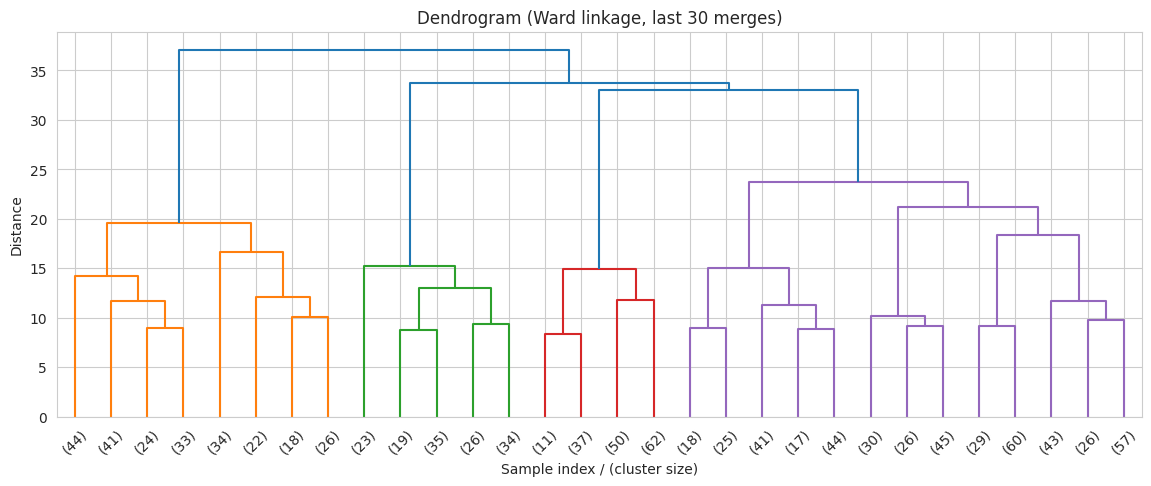

In [31]:
# 10.12 Dendrogram (Dendrogram dataset)
Z = linkage(X_dendro, method='ward')

plt.figure(figsize=(14, 5))
dendrogram(Z, truncate_mode='lastp', p=30)
plt.title("Dendrogram (Ward linkage, last 30 merges)")
plt.xlabel("Sample index / (cluster size)"); plt.ylabel("Distance")
plt.show()
cleanup()

## Part 11 — Algorithm Comparison (All Metrics)

In [32]:
comparison_df = pd.DataFrame(results).T
comparison_df['runtime_s'] = pd.Series(runtime_store)
comparison_df = comparison_df.sort_values('silhouette', ascending=False)
comparison_df

,silhouette,davies_bouldin,dunn,calinski_harabasz,n_clusters,noise_pct,runtime_s
OPTICS,0.385347,1.050768,0.478094,40.495154,5.0,98.400000,6.920102
HDBSCAN,0.267320,1.577277,0.309348,109.281460,2.0,96.020000,11.049101
Agglomerative (Single),0.161628,0.644298,0.367227,2.382644,3.0,0.000000,1.740385
Kernel K-Means,0.119442,2.441334,0.081933,613.450964,3.0,0.000000,24.696185
K-Means,0.117931,2.430272,0.015336,4642.508294,3.0,0.000000,4.082988
Agglomerative (Ward),0.104343,2.503776,0.087930,577.124897,3.0,0.000000,3.845293
Bisecting K-Means,0.083562,2.702431,0.025155,3931.554553,3.0,0.000000,0.173171
Fuzzy C-Means,0.061975,2.790544,0.037737,674.647180,3.0,0.000000,0.067057
K-Medoids,0.054058,3.833714,0.055313,370.070231,3.0,0.000000,5.911543
K-Median,0.047089,3.710858,0.042939,438.554650,3.0,0.000000,0.092670


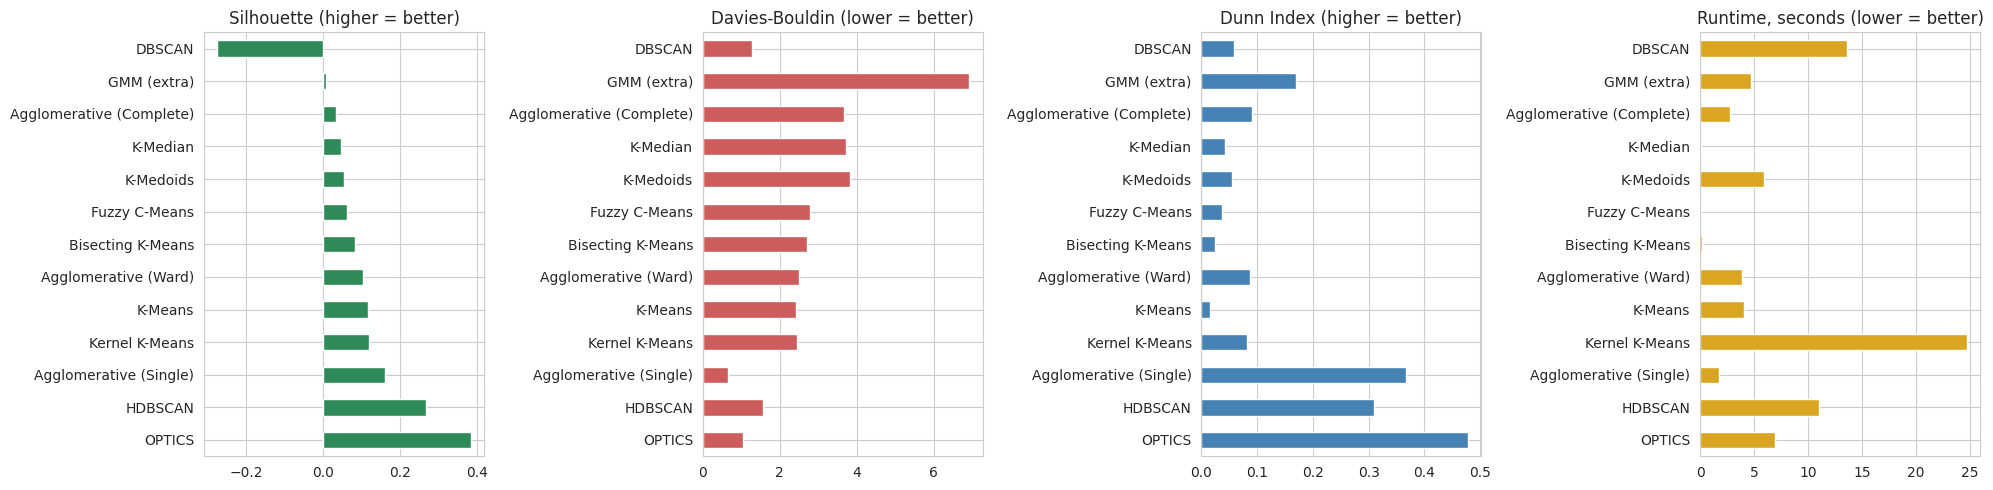

In [33]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

comparison_df['silhouette'].dropna().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title("Silhouette (higher = better)")

comparison_df['davies_bouldin'].dropna().plot(kind='barh', ax=axes[1], color='indianred')
axes[1].set_title("Davies-Bouldin (lower = better)")

comparison_df['dunn'].dropna().plot(kind='barh', ax=axes[2], color='steelblue')
axes[2].set_title("Dunn Index (higher = better)")

comparison_df['runtime_s'].plot(kind='barh', ax=axes[3], color='goldenrod')
axes[3].set_title("Runtime, seconds (lower = better)")

plt.tight_layout()
plt.show()

In [34]:
# 11.1 Holistic Best-Model Selection
def holistic_best_model(df_in, min_clusters=2, max_noise_pct=50):
    eligible = df_in[
        (df_in['n_clusters'] >= min_clusters) &
        (df_in['noise_pct'] <= max_noise_pct)
    ].dropna(subset=['silhouette'])
    if eligible.empty:
        return df_in['silhouette'].idxmax()
    return eligible['silhouette'].idxmax()

best_model_name = holistic_best_model(comparison_df)
rejected = list(comparison_df.index[(comparison_df['n_clusters'] < 2) | (comparison_df['noise_pct'] > 50)])
print("Rejected (degenerate):", rejected)
print("\nHolistically selected:", best_model_name)
comparison_df.loc[best_model_name]

Rejected (degenerate): ['OPTICS', 'HDBSCAN']

Holistically selected: Agglomerative (Single)


,Agglomerative (Single)
silhouette,0.161628
davies_bouldin,0.644298
dunn,0.367227
calinski_harabasz,2.382644
n_clusters,3.000000
noise_pct,0.000000
runtime_s,1.740385


## Part 12 — Enhanced Cluster Profiling

In [35]:
best_labels = labels_store[best_model_name]
best_dataset_name = dataset_used_store[best_model_name]
_, best_idx = dataset_lookup[best_dataset_name]

df_profile = df.iloc[best_idx].copy().reset_index(drop=True)
df_profile['cluster'] = best_labels

print(f"Profiling '{best_model_name}' ({df_profile.shape[0]:,} rows, "
      f"{df_profile['cluster'].nunique()} clusters)")

Profiling 'Agglomerative (Single)' (7,000 rows, 3 clusters)


Numeric feature distributions per cluster:


age                       balance                         \
              mean        std median        mean          std    median   
cluster                                                                   
0        41.184441  10.881856   39.0   953.96521  1187.134155   463.000   
1        73.000000        NaN   73.0  3506.37500          NaN  3506.375   
2        42.000000        NaN   42.0   147.00000          NaN   147.000   

               day                     duration                          \
              mean       std median        mean         std      median   
cluster                                                                   
0        15.705729  8.214394   16.0  242.112030  182.662186  183.000000   
1        29.000000       NaN   29.0  153.000000         NaN  153.000000   
2         3.000000       NaN    3.0  651.753723         NaN  651.753723   

         campaign                   
             mean       std median  
cluster                             
0        2.417691  1.622608    2.0  
1        4.000000       NaN    4.0  
2        6.000000       NaN    6.0

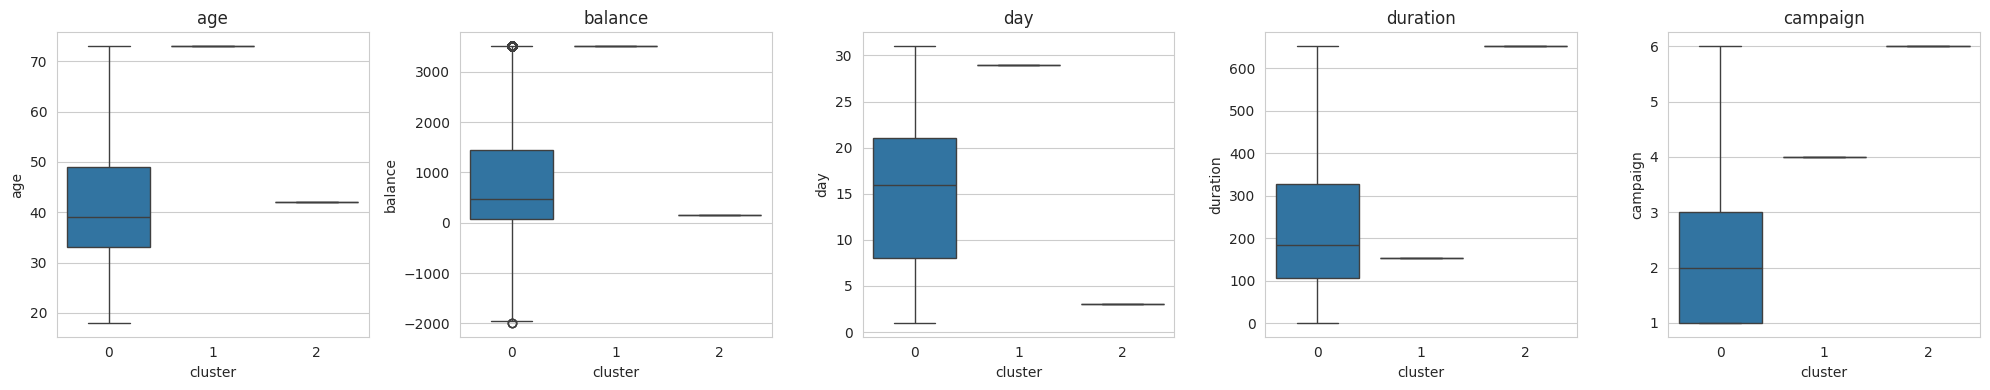

In [36]:
# 12.1 Numerical distributions per cluster
profile_numeric = df_profile.groupby('cluster')[num_cols].agg(['mean', 'std', 'median'])
print("Numeric feature distributions per cluster:")
display(profile_numeric)

fig, axes = plt.subplots(1, len(num_cols), figsize=(4*len(num_cols), 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(data=df_profile, x='cluster', y=col, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [37]:
# 12.2 Categorical distributions per cluster
for c in cat_cols:
    print(f"\n--- '{c}' distribution per cluster ---")
    props = df_profile.groupby('cluster')[c].value_counts(normalize=True).unstack().fillna(0)
    dominant = props.idxmax(axis=1)
    dominant_share = props.max(axis=1)
    summary = pd.DataFrame({'dominant_category': dominant, 'share': dominant_share})
    print(summary)


--- 'job' distribution per cluster ---
        dominant_category    share
cluster                           
0              management  0.20363
1                 unknown  1.00000
2              technician  1.00000

--- 'marital' distribution per cluster ---
        dominant_category     share
cluster                            
0                 married  0.568162
1                  single  1.000000
2                divorced  1.000000

--- 'education' distribution per cluster ---
        dominant_category     share
cluster                            
0               secondary  0.476565
1                tertiary  1.000000
2                 unknown  1.000000

--- 'default' distribution per cluster ---
        dominant_category     share
cluster                            
0                      no  0.932552
1                      no  1.000000
2                 unknown  1.000000

--- 'housing' distribution per cluster ---
        dominant_category     share
cluster                        

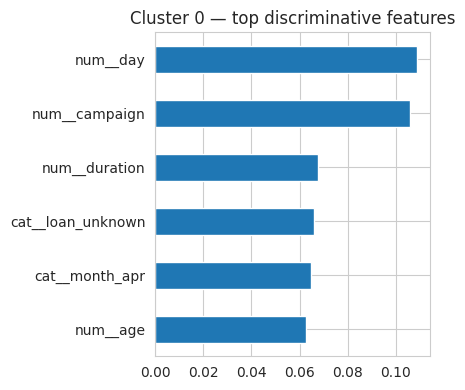

In [38]:
# 12.3 Feature importance WITHIN clusters (one-vs-rest RF per cluster)
X_profile_encoded = preprocessor.transform(df_profile.drop(columns=['y', 'cluster'])).astype(np.float64)
profile_feature_names = preprocessor.get_feature_names_out()

cluster_feature_importance = {}
for cl in sorted(df_profile['cluster'].unique()):
    y_ovr = (df_profile['cluster'] == cl).astype(int).values
    if y_ovr.sum() < 5 or y_ovr.sum() == len(y_ovr):
        continue
    rf_ovr = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=RANDOM_STATE,
                                     class_weight='balanced').fit(X_profile_encoded, y_ovr)
    imp = pd.Series(rf_ovr.feature_importances_, index=profile_feature_names).sort_values(ascending=False)
    cluster_feature_importance[cl] = imp

fig, axes = plt.subplots(1, len(cluster_feature_importance), figsize=(4.5*len(cluster_feature_importance), 4))
axes = np.atleast_1d(axes)
for ax, (cl, imp) in zip(axes, cluster_feature_importance.items()):
    imp.head(6).plot(kind='barh', ax=ax)
    ax.invert_yaxis()
    ax.set_title(f"Cluster {cl} — top discriminative features")
plt.tight_layout()
plt.show()

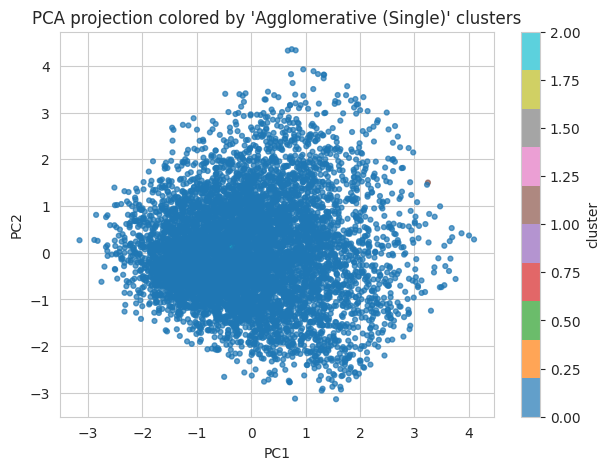

In [39]:
# 12.4 PCA projection colored by the best model's clusters
X_best_pca = pca.transform(dataset_lookup[best_dataset_name][0])
plt.figure(figsize=(7,5))
scatter = plt.scatter(X_best_pca[:,0], X_best_pca[:,1], c=best_labels, cmap='tab10', s=12, alpha=0.7)
plt.title(f"PCA projection colored by '{best_model_name}' clusters")
plt.xlabel("PC1"); plt.ylabel("PC2")
plt.colorbar(scatter, label='cluster')
plt.show()

## Part 13 — Noise Resistance Experiments (ALL Algorithms)

In [40]:
def add_noise(X, frac=0.1, scale=3.0, random_state=42):
    rng = np.random.RandomState(random_state)
    X_noisy = X.copy()
    n_noise = int(frac * X.shape[0])
    idx = rng.choice(X.shape[0], n_noise, replace=False)
    X_noisy[idx] += rng.normal(0, scale, size=(n_noise, X.shape[1]))
    return X_noisy

# Refit functions for each algorithm
refit_functions = {
    'K-Means': lambda Xn: KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(Xn).labels_,
    'Bisecting K-Means': lambda Xn: BisectingKMeans(n_clusters=best_k, random_state=RANDOM_STATE).fit(Xn).labels_,
    'DBSCAN': lambda Xn: DBSCAN(eps=eps_choice, min_samples=5).fit(Xn).labels_,
    'OPTICS': lambda Xn: OPTICS(min_samples=10).fit(Xn).labels_,
    'HDBSCAN': lambda Xn: HDBSCAN(min_cluster_size=30).fit(Xn).labels_,
    'GMM (extra)': lambda Xn: GaussianMixture(n_components=best_k, random_state=RANDOM_STATE).fit(Xn).predict(Xn),
    'K-Medoids': lambda Xn: k_medoids(Xn, best_k, random_state=RANDOM_STATE)[0],
    'K-Median': lambda Xn: k_median(Xn, best_k, random_state=RANDOM_STATE)[0],
    'Fuzzy C-Means': lambda Xn: fuzzy_c_means(Xn, best_k, random_state=RANDOM_STATE)[0],
    'Kernel K-Means': lambda Xn: kernel_kmeans(Xn, best_k, random_state=RANDOM_STATE),
    'Agglomerative (Ward)': lambda Xn: AgglomerativeClustering(n_clusters=best_k, linkage='ward').fit(Xn).labels_,
    'Agglomerative (Single)': lambda Xn: AgglomerativeClustering(n_clusters=best_k, linkage='single').fit(Xn).labels_,
    'Agglomerative (Complete)': lambda Xn: AgglomerativeClustering(n_clusters=best_k, linkage='complete').fit(Xn).labels_,
}

NOISE_LEVELS = [0.05, 0.15]
STABILITY_REPEATS = 2

print(f"Running noise experiments: {len(refit_functions)} algorithms x {len(NOISE_LEVELS)} "
      f"noise levels x {STABILITY_REPEATS} repeats = "
      f"{len(refit_functions)*len(NOISE_LEVELS)*STABILITY_REPEATS} refits.")

Running noise experiments: 13 algorithms x 2 noise levels x 2 repeats = 52 refits.


In [41]:
noise_rows = []

for name, refit_fn in refit_functions.items():
    ds_name = dataset_used_store[name]
    X_ds, _ = dataset_lookup[ds_name]
    original_labels = labels_store[name]
    original_runtime = runtime_store[name]

    for noise_frac in NOISE_LEVELS:
        aris = []
        sils = []
        runtimes = []
        for rep in range(STABILITY_REPEATS):
            seed = RANDOM_STATE + rep
            X_noisy = add_noise(X_ds, frac=noise_frac, scale=3.0, random_state=seed)
            t0 = time.time()
            try:
                noisy_labels = refit_fn(X_noisy)
            except Exception as e:
                print(f"  [skip] {name} @ noise={noise_frac}: {e}")
                continue
            elapsed = time.time() - t0

            ari = adjusted_rand_score(original_labels, noisy_labels)
            aris.append(ari)
            runtimes.append(elapsed)

            mask = noisy_labels != -1
            if len(set(np.asarray(noisy_labels)[mask])) >= 2:
                sils.append(silhouette_score(X_noisy[mask], np.asarray(noisy_labels)[mask]))

        if not aris:
            continue

        noise_rows.append({
            'algorithm': name,
            'noise_level': noise_frac,
            'mean_ari_robustness': np.mean(aris),
            'stability_ari_std': np.std(aris),
            'mean_silhouette_noisy': np.mean(sils) if sils else np.nan,
            'mean_runtime_s': np.mean(runtimes),
            'runtime_degradation_x': np.mean(runtimes) / original_runtime if original_runtime > 0 else np.nan,
        })
    cleanup()
    print(f"  done: {name}")

noise_results_df = pd.DataFrame(noise_rows)
noise_results_df

  done: K-Means
  done: Bisecting K-Means
  done: DBSCAN
  done: OPTICS
  done: HDBSCAN
  done: GMM (extra)
  done: K-Medoids
  done: K-Median
  done: Fuzzy C-Means
  done: Kernel K-Means
  done: Agglomerative (Ward)
  done: Agglomerative (Single)
  done: Agglomerative (Complete)


,algorithm,noise_level,mean_ari_robustness,stability_ari_std,mean_silhouette_noisy,mean_runtime_s,runtime_degradation_x
0,K-Means,0.05,0.883874,0.001573,0.115785,3.092906,0.757511
1,K-Means,0.15,0.705096,0.002388,0.103624,3.514902,0.860865
2,Bisecting K-Means,0.05,0.176500,0.050152,0.139051,0.409363,2.363919
3,Bisecting K-Means,0.15,0.051319,0.051368,0.359146,0.384148,2.218310
4,DBSCAN,0.05,0.846992,0.000808,-0.274695,13.472574,0.987338
5,DBSCAN,0.15,0.582701,0.001098,-0.264950,13.445475,0.985352
6,OPTICS,0.05,0.763454,0.092945,0.371433,6.668363,0.963622
7,OPTICS,0.15,0.057786,0.067981,0.357943,6.651245,0.961148
8,HDBSCAN,0.05,0.926549,0.011570,0.254172,13.485561,1.220512
9,HDBSCAN,0.15,0.833557,0.022546,0.286037,13.850152,1.253509


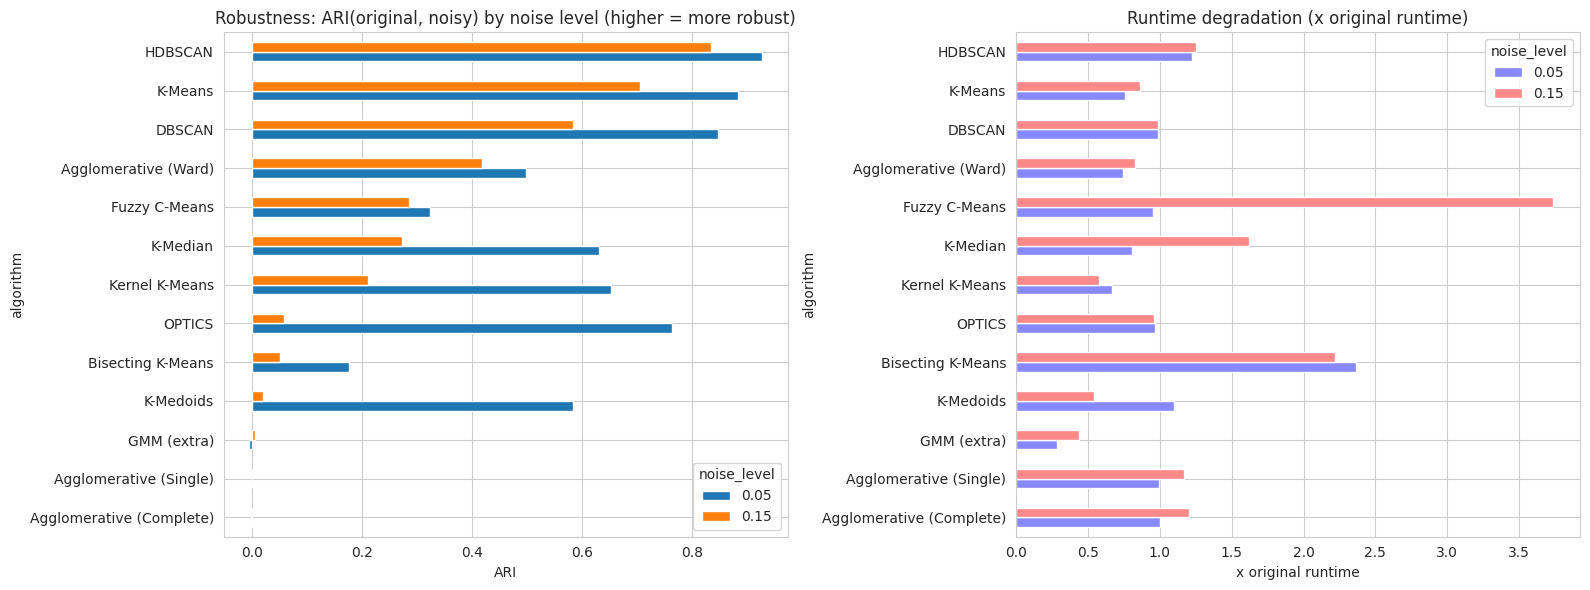

In [42]:
# Visual comparison: robustness (ARI) by algorithm and noise level
pivot_ari = noise_results_df.pivot(index='algorithm', columns='noise_level', values='mean_ari_robustness')
pivot_ari = pivot_ari.sort_values(pivot_ari.columns[-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
pivot_ari.plot(kind='barh', ax=axes[0])
axes[0].set_title("Robustness: ARI(original, noisy) by noise level (higher = more robust)")
axes[0].set_xlabel("ARI")

pivot_degrad = noise_results_df.pivot(index='algorithm', columns='noise_level', values='runtime_degradation_x')
pivot_degrad = pivot_degrad.reindex(pivot_ari.index)
pivot_degrad.plot(kind='barh', ax=axes[1], color=['#8888ff', '#ff8888'])
axes[1].set_title("Runtime degradation (x original runtime)")
axes[1].set_xlabel("x original runtime")

plt.tight_layout()
plt.show()

## Part 14 — Nonlinear Shape Detection (Two-Moons)

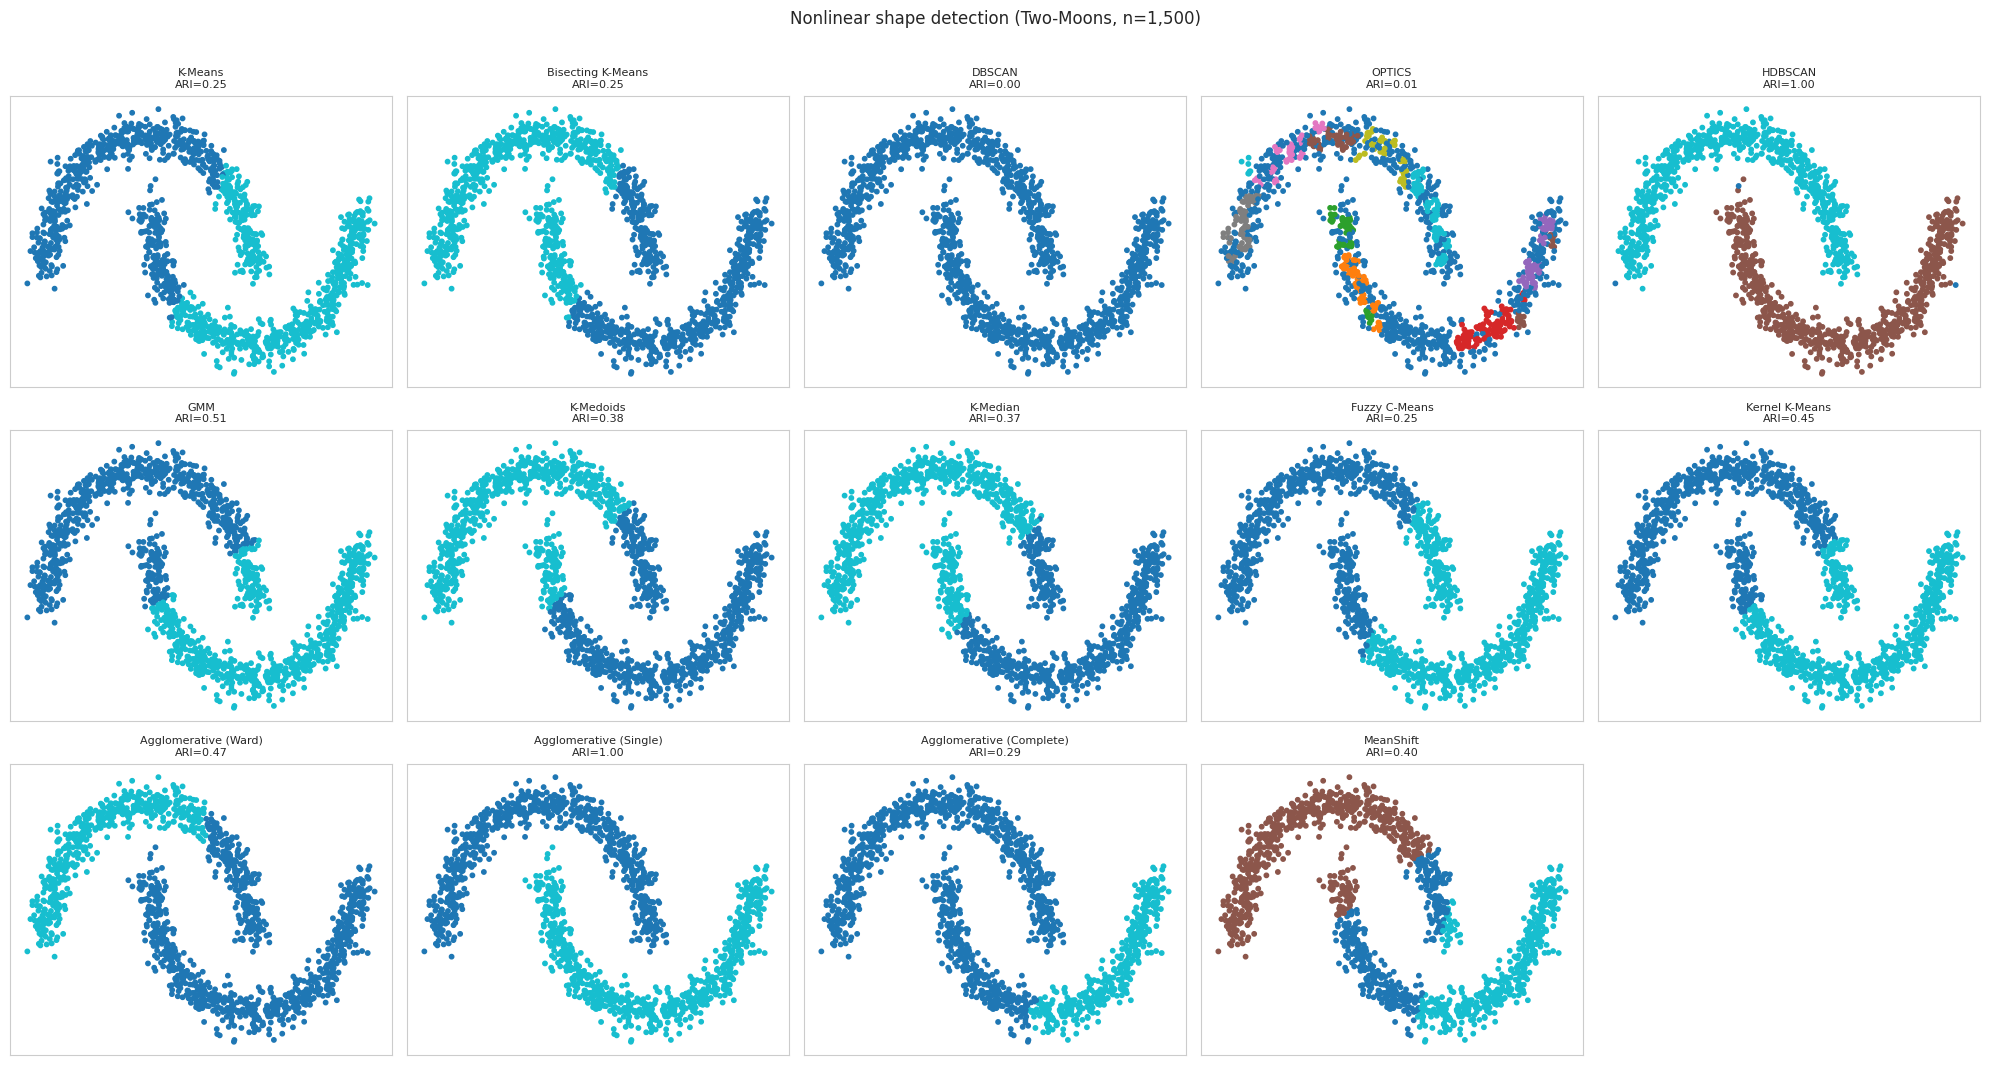

,ARI vs. true moons
Agglomerative (Single),1.000000
HDBSCAN,0.996003
GMM,0.510422
Agglomerative (Ward),0.465713
Kernel K-Means,0.453013
MeanShift,0.399438
K-Medoids,0.382340
K-Median,0.372495
Agglomerative (Complete),0.294115
K-Means,0.252175


In [43]:
from sklearn.cluster import MeanShift, estimate_bandwidth

Xm, ym_true = make_moons(n_samples=1500, noise=0.07, random_state=RANDOM_STATE)

bandwidth = estimate_bandwidth(Xm, quantile=0.2, random_state=RANDOM_STATE)

algos_nonlinear = {
    'K-Means': KMeans(n_clusters=2, n_init=10, random_state=RANDOM_STATE).fit_predict(Xm),
    'Bisecting K-Means': BisectingKMeans(n_clusters=2, random_state=RANDOM_STATE).fit_predict(Xm),
    'DBSCAN': DBSCAN(eps=0.2, min_samples=5).fit_predict(Xm),
    'OPTICS': OPTICS(min_samples=5).fit_predict(Xm),
    'HDBSCAN': HDBSCAN(min_cluster_size=15).fit_predict(Xm),
    'GMM': GaussianMixture(n_components=2, random_state=RANDOM_STATE).fit_predict(Xm),
    'K-Medoids': k_medoids(Xm, 2, random_state=RANDOM_STATE)[0],
    'K-Median': k_median(Xm, 2, random_state=RANDOM_STATE)[0],
    'Fuzzy C-Means': fuzzy_c_means(Xm, 2, random_state=RANDOM_STATE)[0],
    'Kernel K-Means': kernel_kmeans(Xm, 2, gamma=3, random_state=RANDOM_STATE),
    'Agglomerative (Ward)': AgglomerativeClustering(n_clusters=2, linkage='ward').fit_predict(Xm),
    'Agglomerative (Single)': AgglomerativeClustering(n_clusters=2, linkage='single').fit_predict(Xm),
    'Agglomerative (Complete)': AgglomerativeClustering(n_clusters=2, linkage='complete').fit_predict(Xm),
    'MeanShift': MeanShift(bandwidth=bandwidth).fit_predict(Xm),
}

n_algos = len(algos_nonlinear)
n_cols = 5
n_rows = int(np.ceil(n_algos / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 3.5*n_rows))
axes = np.array(axes).reshape(-1)

nonlinear_ari = {}
for ax, (name, labels) in zip(axes, algos_nonlinear.items()):
    ax.scatter(Xm[:, 0], Xm[:, 1], c=labels, cmap='tab10', s=10)
    ari = adjusted_rand_score(ym_true, labels)
    nonlinear_ari[name] = ari
    ax.set_title(f"{name}\nARI={ari:.2f}", fontsize=8)
    ax.set_xticks([]); ax.set_yticks([])

for ax in axes[n_algos:]:
    ax.axis('off')
plt.suptitle(f"Nonlinear shape detection (Two-Moons, n={Xm.shape[0]:,})", y=1.01)
plt.tight_layout()
plt.show()

pd.Series(nonlinear_ari, name='ARI vs. true moons').sort_values(ascending=False)

## Part 15 — Feature Removal Experiments (Clustering)

Per the assignment feedback, **'day' and 'month' are NOT removed** — feature importance
shows they are useful. Instead, we test the effect of removing (a) the least important
features, (b) highly correlated features (if any), and (c) post-event information
(`duration`, which is only known after a call completes).

In [44]:
def original_col_name(feat_name):
    prefix, rest = feat_name.split('__', 1)
    if prefix == 'num':
        return rest
    for c in cat_cols:
        if rest.startswith(c):
            return c
    return rest

col_importance = feature_ranking.copy()
col_importance['original_col'] = [original_col_name(f) for f in col_importance.index]
col_agg = col_importance.groupby('original_col')['combined_score'].sum().sort_values(ascending=False)
print("Aggregated importance by original column:")
print(col_agg)

least_important_cols = col_agg.index[-2:].tolist()
print("\nLeast important original columns (candidates for removal):", least_important_cols)

Aggregated importance by original column:
original_col
duration     0.322958
month        0.126772
balance      0.086246
housing      0.082987
job          0.072399
age          0.070189
day          0.058833
education    0.044667
loan         0.040475
marital      0.038345
campaign     0.033329
default      0.022801
Name: combined_score, dtype: float64

Least important original columns (candidates for removal): ['campaign', 'default']


In [45]:
def silhouette_for_feature_set(exclude_cols, sample_idx=idx_visual):
    nc = [c for c in num_cols if c not in exclude_cols]
    cc = [c for c in cat_cols if c not in exclude_cols]
    pre = ColumnTransformer([
        ('num', StandardScaler(), nc),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cc)
    ])
    X_variant = pre.fit_transform(X_cluster_df).astype(np.float64)
    km_variant = MiniBatchKMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE,
                                  batch_size=1000).fit(X_variant)
    sil = silhouette_score(X_variant[sample_idx], km_variant.predict(X_variant[sample_idx]))
    return sil, X_variant.shape[1]

feature_removal_rows = []

sil_baseline, n_feat_baseline = silhouette_for_feature_set(exclude_cols=[])
feature_removal_rows.append({'experiment': 'Baseline (all features)', 'removed': 'none',
                              'silhouette': sil_baseline, 'n_encoded_features': n_feat_baseline})

sil_least_imp, n_feat_li = silhouette_for_feature_set(exclude_cols=least_important_cols)
feature_removal_rows.append({'experiment': 'Remove least important', 'removed': str(least_important_cols),
                              'silhouette': sil_least_imp, 'n_encoded_features': n_feat_li})

if high_corr_pairs:
    corr_drop = [p[1] for p in high_corr_pairs]
    sil_corr, n_feat_corr = silhouette_for_feature_set(exclude_cols=corr_drop)
    feature_removal_rows.append({'experiment': 'Remove highly-correlated', 'removed': str(corr_drop),
                                  'silhouette': sil_corr, 'n_encoded_features': n_feat_corr})
else:
    feature_removal_rows.append({'experiment': 'Remove highly-correlated', 'removed': 'none found (>0.8)',
                                  'silhouette': sil_baseline, 'n_encoded_features': n_feat_baseline})

sil_no_duration, n_feat_nd = silhouette_for_feature_set(exclude_cols=['duration'])
feature_removal_rows.append({'experiment': 'Remove post-event info (duration)', 'removed': "['duration']",
                              'silhouette': sil_no_duration, 'n_encoded_features': n_feat_nd})

feature_removal_df = pd.DataFrame(feature_removal_rows)
feature_removal_df['change_vs_baseline'] = feature_removal_df['silhouette'] - sil_baseline
feature_removal_df

,experiment,removed,silhouette,n_encoded_features,change_vs_baseline
0,Baseline (all features),none,0.112959,47,0.000000
1,Remove least important,"['campaign', 'default']",0.102396,43,-0.010564
2,Remove highly-correlated,none found (>0.8),0.112959,47,0.000000
3,Remove post-event info (duration),['duration'],0.109188,46,-0.003771


## Part 16 — Classification

In [46]:
# 16.1 Target Selection & Train/Test Split
df_clf = df[df['y'] != 'unknown'].copy()
df_clf['y'] = (df_clf['y'] == 'yes').astype(int)

print("Class distribution:")
print(df_clf['y'].value_counts())
print(df_clf['y'].value_counts(normalize=True))

X_feat = df_clf.drop(columns=['y'])
y_target = df_clf['y']

X_train, X_test, y_train, y_test = train_test_split(
    X_feat, y_target, test_size=0.2, random_state=RANDOM_STATE, stratify=y_target
)
print(f"Train: {X_train.shape[0]:,}, Test: {X_test.shape[0]:,}")

Class distribution:
y
0    37832
1     5024
Name: count, dtype: int64
y
0    0.88277
1    0.11723
Name: proportion, dtype: float64
Train: 34,284, Test: 8,572


In [47]:
# 16.2 Feature Preprocessing
preprocessor_clf = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

In [48]:
# 16.3 CPU-Based Models (with GridSearchCV)
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'Decision Tree': DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
}

param_grids = {
    'Logistic Regression': {'clf__C': [0.01, 0.1, 1, 10]},
    'Decision Tree': {'clf__max_depth': [3, 5, 7, None], 'clf__min_samples_split': [2, 10, 20]},
    'Random Forest': {'clf__n_estimators': [100, 200], 'clf__max_depth': [5, 10, None]},
}

fitted_models = {}
clf_results = []

for name, model in models.items():
    pipe = Pipeline([('pre', preprocessor_clf), ('clf', model)])
    t0 = time.time()
    if name in param_grids:
        gs = GridSearchCV(pipe, param_grids[name], scoring='f1',
                           cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE), n_jobs=-1)
        gs.fit(X_train, y_train)
        best_pipe = gs.best_estimator_
        print(f"{name}: {gs.best_params_}")
    else:
        best_pipe = pipe.fit(X_train, y_train)
    train_time = time.time() - t0

    fitted_models[name] = best_pipe
    y_pred = best_pipe.predict(X_test)
    y_proba = best_pipe.predict_proba(X_test)[:, 1]

    clf_results.append({
        'model': name,
        'f1': f1_score(y_test, y_pred),
        'auc_roc': roc_auc_score(y_test, y_proba),
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'train_time_s': train_time,
    })

pd.DataFrame(clf_results)

Logistic Regression: {'clf__C': 0.1}
Decision Tree: {'clf__max_depth': 7, 'clf__min_samples_split': 2}
Random Forest: {'clf__max_depth': 10, 'clf__n_estimators': 100}


,model,f1,auc_roc,accuracy,precision,recall,train_time_s
0,Logistic Regression,0.486022,0.873502,0.804830,0.351556,0.787065,8.879068
1,Decision Tree,0.430058,0.846840,0.738101,0.288684,0.842786,15.303579
2,Naive Bayes,0.370095,0.775194,0.861409,0.396141,0.347264,0.103947
3,Random Forest,0.487164,0.879705,0.804246,0.351566,0.793035,113.189563


In [49]:
# 16.4 XGBoost with Early Stopping
preprocessor_gpu = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])
Xtr_proc = preprocessor_gpu.fit_transform(X_train).astype(np.float64)
Xte_proc = preprocessor_gpu.transform(X_test).astype(np.float64)

Xtr_sub, Xval, ytr_sub, yval = train_test_split(
    Xtr_proc, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print("scale_pos_weight:", round(scale_pos_weight, 2))

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_pos_weight,
    tree_method='hist', device=XGB_DEVICE,
    eval_metric='logloss', early_stopping_rounds=50,
    random_state=RANDOM_STATE
)

t0 = time.time()
xgb_clf.fit(Xtr_sub, ytr_sub, eval_set=[(Xval, yval)], verbose=False)
xgb_train_time = time.time() - t0
print(f"XGBoost trained in {xgb_train_time:.2f}s on '{XGB_DEVICE}'")
print(f"Best iteration: {xgb_clf.best_iteration}")

y_pred_xgb = xgb_clf.predict(Xte_proc)
y_proba_xgb = xgb_clf.predict_proba(Xte_proc)[:, 1]

clf_results.append({
    'model': 'XGBoost',
    'f1': f1_score(y_test, y_pred_xgb),
    'auc_roc': roc_auc_score(y_test, y_proba_xgb),
    'accuracy': accuracy_score(y_test, y_pred_xgb),
    'precision': precision_score(y_test, y_pred_xgb),
    'recall': recall_score(y_test, y_pred_xgb),
    'train_time_s': xgb_train_time,
})
print(f"XGBoost -> F1: {clf_results[-1]['f1']:.3f}, AUC: {clf_results[-1]['auc_roc']:.3f}")

scale_pos_weight: 7.53
XGBoost trained in 4.80s on 'cpu'
Best iteration: 299
XGBoost -> F1: 0.550, AUC: 0.907


In [50]:
# 16.5 Comprehensive Evaluation
clf_results_df = pd.DataFrame(clf_results).sort_values('f1', ascending=False).reset_index(drop=True)
clf_results_df

,model,f1,auc_roc,accuracy,precision,recall,train_time_s
0,XGBoost,0.550067,0.907176,0.842744,0.413862,0.819900,4.795570
1,Random Forest,0.487164,0.879705,0.804246,0.351566,0.793035,113.189563
2,Logistic Regression,0.486022,0.873502,0.804830,0.351556,0.787065,8.879068
3,Decision Tree,0.430058,0.846840,0.738101,0.288684,0.842786,15.303579
4,Naive Bayes,0.370095,0.775194,0.861409,0.396141,0.347264,0.103947


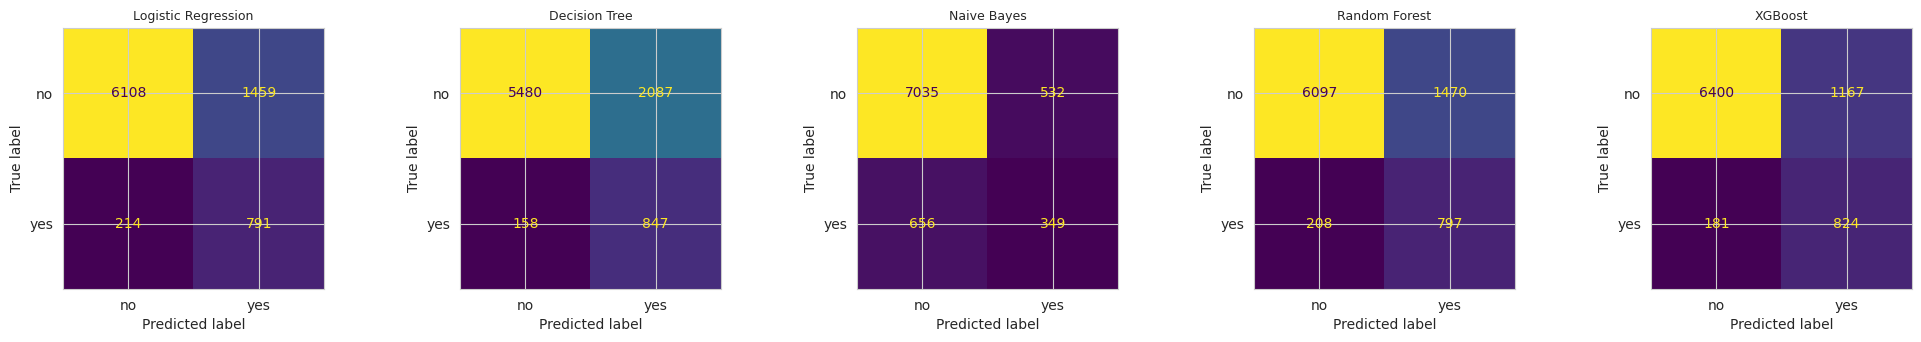

In [51]:
# Confusion Matrices
fig, axes = plt.subplots(1, len(fitted_models) + 1, figsize=(4*(len(fitted_models)+1), 3.5))
plot_models = {**fitted_models, 'XGBoost': None}
for ax, name in zip(axes, plot_models):
    y_pred = fitted_models[name].predict(X_test) if name in fitted_models else y_pred_xgb
    ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred), display_labels=['no','yes']).plot(ax=ax, colorbar=False)
    ax.set_title(name, fontsize=9)
plt.tight_layout()
plt.show()

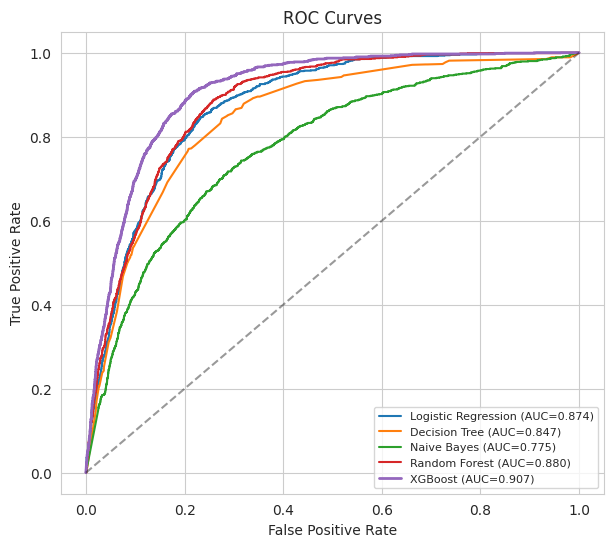

In [52]:
# ROC Curves
plt.figure(figsize=(7,6))
for name, pipe in fitted_models.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, y_proba):.3f})")

fpr_x, tpr_x, _ = roc_curve(y_test, y_proba_xgb)
plt.plot(fpr_x, tpr_x, label=f"XGBoost (AUC={roc_auc_score(y_test, y_proba_xgb):.3f})", lw=2)

plt.plot([0,1],[0,1],'k--', alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curves"); plt.legend(fontsize=8)
plt.show()

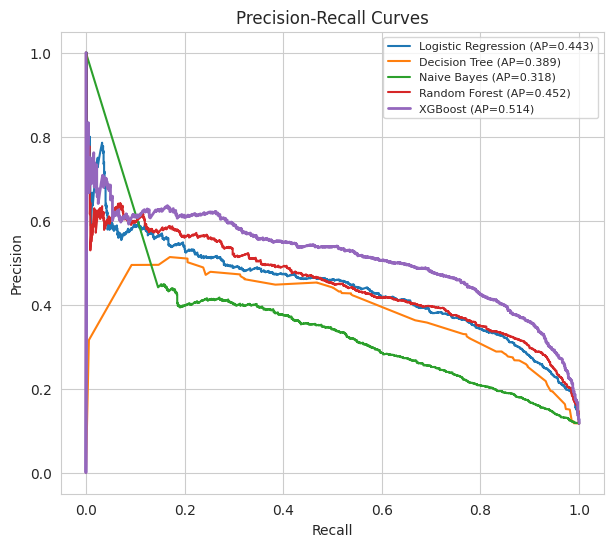

In [53]:
# Precision-Recall Curves
plt.figure(figsize=(7,6))
for name, pipe in fitted_models.items():
    y_proba = pipe.predict_proba(X_test)[:, 1]
    prec, rec, _ = precision_recall_curve(y_test, y_proba)
    plt.plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, y_proba):.3f})")

prec_x, rec_x, _ = precision_recall_curve(y_test, y_proba_xgb)
plt.plot(rec_x, prec_x, label=f"XGBoost (AP={average_precision_score(y_test, y_proba_xgb):.3f})", lw=2)

plt.xlabel("Recall"); plt.ylabel("Precision")
plt.title("Precision-Recall Curves"); plt.legend(fontsize=8)
plt.show()

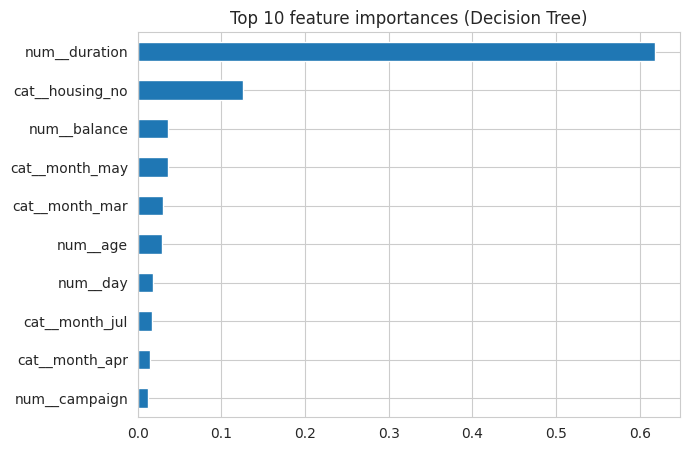

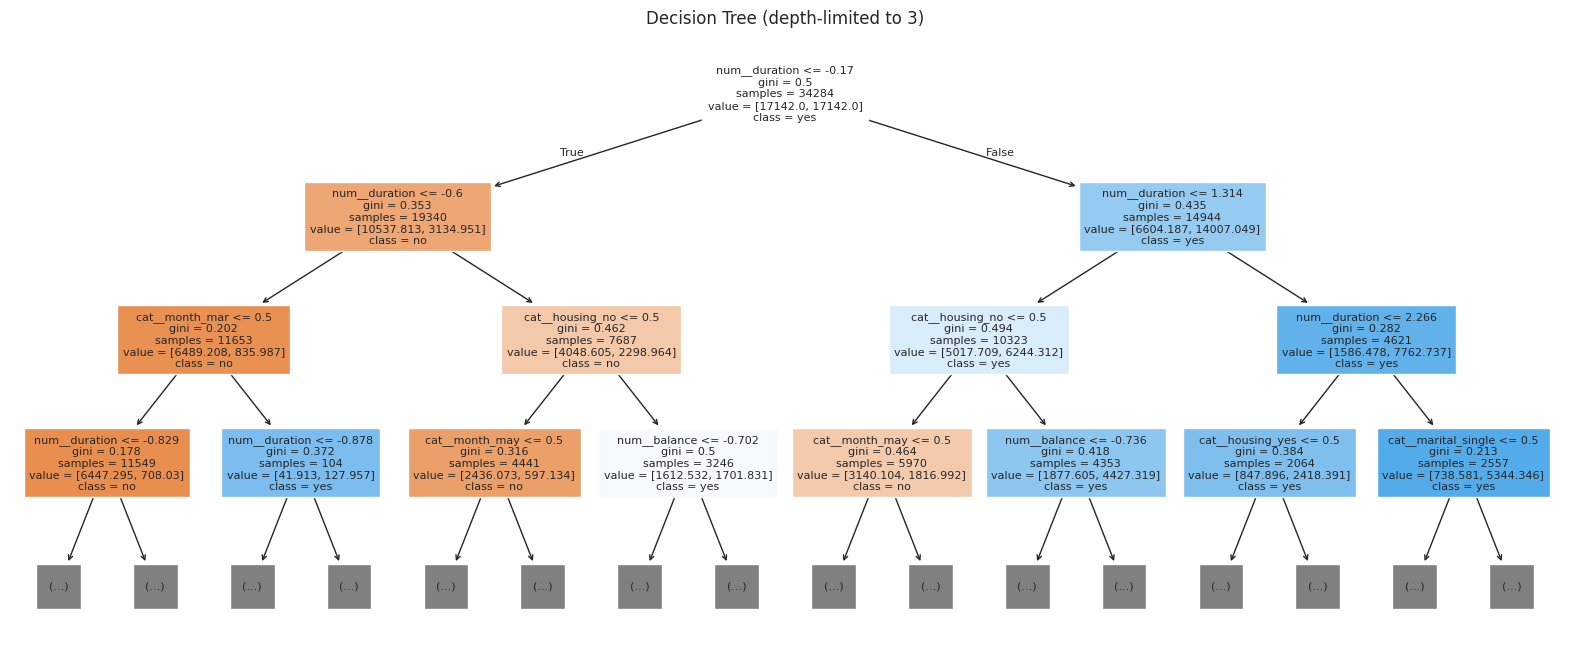

|--- num__duration <= -0.17
|   |--- num__duration <= -0.60
|   |   |--- cat__month_mar <= 0.50
|   |   |   |--- num__duration <= -0.83
|   |   |   |   |--- cat__month_feb <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- cat__month_feb >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- num__duration >  -0.83
|   |   |   |   |--- cat__month_apr <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- cat__month_apr >  0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |--- cat__month_mar >  0.50
|   |   |   |--- num__duration <= -0.88
|   |   |   |   |--- num__balance <= -0.36
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- num__balance >  -0.36
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- num__duration >  -0.88
|   |   |   |   |--- cat__job_blue-collar <= 0.50
|   |   |   |   |   |--- truncated branch of depth 3
|   |   |   |   |--- cat_

In [54]:
# 16.6 Decision Tree Analysis
dt_pipe = fitted_models['Decision Tree']
dt_model = dt_pipe.named_steps['clf']
feat_names_clf = dt_pipe.named_steps['pre'].get_feature_names_out()

dt_importances = pd.Series(dt_model.feature_importances_, index=feat_names_clf).sort_values(ascending=False)
plt.figure(figsize=(7,5))
dt_importances.head(10).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 10 feature importances (Decision Tree)")
plt.show()

plt.figure(figsize=(20, 8))
plot_tree(dt_model, feature_names=feat_names_clf, class_names=['no','yes'],
          filled=True, max_depth=3, fontsize=8)
plt.title("Decision Tree (depth-limited to 3)")
plt.show()

print(export_text(dt_model, feature_names=list(feat_names_clf), max_depth=4))

## Part 17 — Cross-Validation

In [55]:
cv_scoring = {'accuracy': 'accuracy', 'precision': 'precision', 'recall': 'recall',
              'f1': 'f1', 'roc_auc': 'roc_auc'}
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_models = {
    'Logistic Regression': Pipeline([('pre', preprocessor_clf),
                                      ('clf', LogisticRegression(max_iter=1000, class_weight='balanced',
                                                                  C=fitted_models['Logistic Regression'].named_steps['clf'].C))]),
    'Decision Tree': Pipeline([('pre', preprocessor_clf),
                                ('clf', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced',
                                    max_depth=fitted_models['Decision Tree'].named_steps['clf'].max_depth,
                                    min_samples_split=fitted_models['Decision Tree'].named_steps['clf'].min_samples_split))]),
    'Naive Bayes': Pipeline([('pre', preprocessor_clf), ('clf', GaussianNB())]),
    'Random Forest': Pipeline([('pre', preprocessor_clf),
                                ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced',
                                    n_estimators=fitted_models['Random Forest'].named_steps['clf'].n_estimators,
                                    max_depth=fitted_models['Random Forest'].named_steps['clf'].max_depth))]),
}

cv_summary_rows = []
for name, pipe in cv_models.items():
    t0 = time.time()
    cv_out = cross_validate(pipe, X_feat, y_target, cv=skf, scoring=cv_scoring, n_jobs=-1)
    elapsed = time.time() - t0
    row = {'model': name, 'cv_time_s': elapsed}
    for metric in cv_scoring:
        scores = cv_out[f'test_{metric}']
        row[f'{metric}_mean'] = scores.mean()
        row[f'{metric}_std'] = scores.std()
    cv_summary_rows.append(row)
    print(f"{name:22s} done in {elapsed:.1f}s")

cv_summary_df = pd.DataFrame(cv_summary_rows)
cv_summary_df

Logistic Regression    done in 1.4s
Decision Tree          done in 1.5s
Naive Bayes            done in 0.8s
Random Forest          done in 14.3s


,model,cv_time_s,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,1.441564,0.801708,0.001844,0.348968,0.001742,0.798765,0.010202,0.485708,0.002365,0.875691,0.003795
1,Decision Tree,1.457866,0.780521,0.004576,0.322450,0.005432,0.791600,0.013915,0.458202,0.006614,0.847197,0.005240
2,Naive Bayes,0.836931,0.858363,0.004487,0.384199,0.019281,0.344348,0.013794,0.363148,0.016026,0.777144,0.006936
3,Random Forest,14.294625,0.810155,0.003177,0.360957,0.003722,0.803541,0.008201,0.498109,0.002990,0.882847,0.004078


In [56]:
# XGBoost cross-validation
xgb_cv_model = xgb.XGBClassifier(
    n_estimators=xgb_clf.best_iteration or 200, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_pos_weight, tree_method='hist', device=XGB_DEVICE,
    eval_metric='logloss', random_state=RANDOM_STATE
)
xgb_cv_pipe = Pipeline([('pre', preprocessor_clf), ('clf', xgb_cv_model)])

t0 = time.time()
xgb_cv_out = cross_validate(xgb_cv_pipe, X_feat, y_target, cv=skf, scoring=cv_scoring, n_jobs=1)
xgb_cv_time = time.time() - t0

xgb_cv_row = {'model': 'XGBoost', 'cv_time_s': xgb_cv_time}
for metric in cv_scoring:
    scores = xgb_cv_out[f'test_{metric}']
    xgb_cv_row[f'{metric}_mean'] = scores.mean()
    xgb_cv_row[f'{metric}_std'] = scores.std()

cv_summary_df = pd.concat([cv_summary_df, pd.DataFrame([xgb_cv_row])], ignore_index=True)
cv_summary_df.sort_values('f1_mean', ascending=False)

,model,cv_time_s,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
4,XGBoost,14.931713,0.838436,0.002604,0.406490,0.005000,0.821852,0.015236,0.543914,0.006870,0.905165,0.004648
3,Random Forest,14.294625,0.810155,0.003177,0.360957,0.003722,0.803541,0.008201,0.498109,0.002990,0.882847,0.004078
0,Logistic Regression,1.441564,0.801708,0.001844,0.348968,0.001742,0.798765,0.010202,0.485708,0.002365,0.875691,0.003795
1,Decision Tree,1.457866,0.780521,0.004576,0.322450,0.005432,0.791600,0.013915,0.458202,0.006614,0.847197,0.005240
2,Naive Bayes,0.836931,0.858363,0.004487,0.384199,0.019281,0.344348,0.013794,0.363148,0.016026,0.777144,0.006936


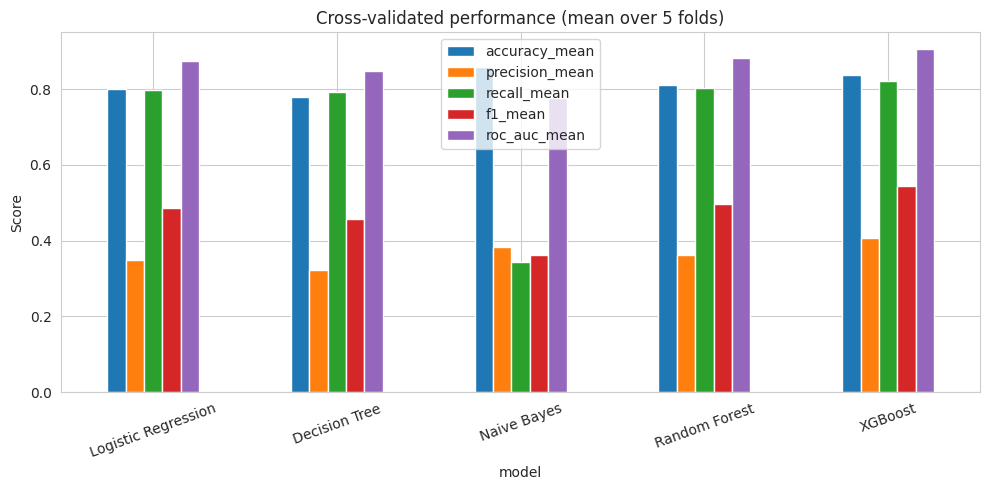

In [57]:
fig, ax = plt.subplots(figsize=(10, 5))
metrics_to_plot = ['accuracy_mean', 'precision_mean', 'recall_mean', 'f1_mean', 'roc_auc_mean']
cv_summary_df.set_index('model')[metrics_to_plot].plot(kind='bar', ax=ax)
ax.set_title("Cross-validated performance (mean over 5 folds)")
ax.set_ylabel("Score")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## Part 18 — Overfitting / Underfitting Analysis

In [58]:
train_val_rows = []
for name, pipe in cv_models.items():
    pipe.fit(X_train, y_train)
    train_score = f1_score(y_train, pipe.predict(X_train))
    test_score = f1_score(y_test, pipe.predict(X_test))
    train_val_rows.append({'model': name, 'train_f1': train_score, 'val_f1': test_score,
                            'overfitting_gap': train_score - test_score})

xgb_cv_pipe.fit(X_train, y_train)
train_score_xgb = f1_score(y_train, xgb_cv_pipe.predict(X_train))
test_score_xgb = f1_score(y_test, xgb_cv_pipe.predict(X_test))
train_val_rows.append({'model': 'XGBoost', 'train_f1': train_score_xgb, 'val_f1': test_score_xgb,
                        'overfitting_gap': train_score_xgb - test_score_xgb})

train_val_df = pd.DataFrame(train_val_rows).sort_values('overfitting_gap', ascending=False)
train_val_df

,model,train_f1,val_f1,overfitting_gap
4,XGBoost,0.617357,0.553724,0.063633
3,Random Forest,0.536312,0.487164,0.049148
1,Decision Tree,0.451112,0.430058,0.021053
0,Logistic Regression,0.486388,0.486022,0.000367
2,Naive Bayes,0.361734,0.370095,-0.008362


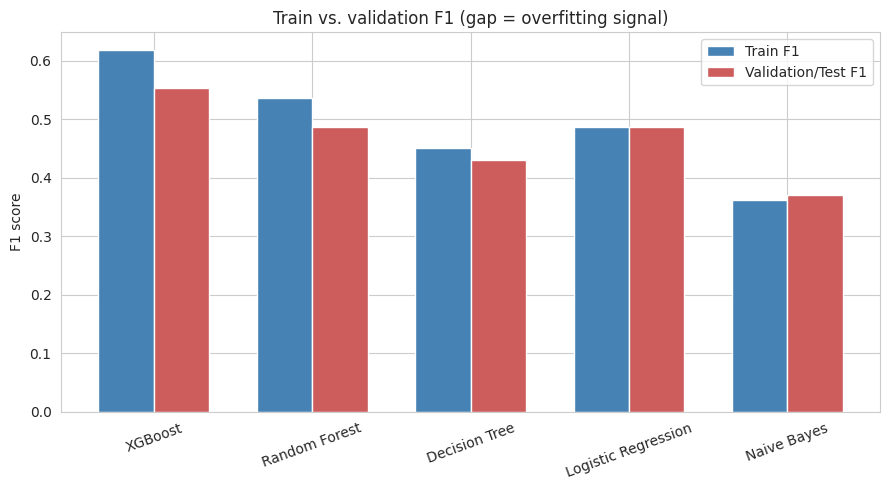

Overfitting gap (train F1 - val F1):
model
XGBoost                0.063633
Random Forest          0.049148
Decision Tree          0.021053
Logistic Regression    0.000367
Naive Bayes           -0.008362
Name: overfitting_gap, dtype: float64


In [59]:
fig, ax = plt.subplots(figsize=(9, 5))
x_pos = np.arange(len(train_val_df))
width = 0.35
ax.bar(x_pos - width/2, train_val_df['train_f1'], width, label='Train F1', color='steelblue')
ax.bar(x_pos + width/2, train_val_df['val_f1'], width, label='Validation/Test F1', color='indianred')
ax.set_xticks(x_pos)
ax.set_xticklabels(train_val_df['model'], rotation=20)
ax.set_ylabel("F1 score")
ax.set_title("Train vs. validation F1 (gap = overfitting signal)")
ax.legend()
plt.tight_layout()
plt.show()

print("Overfitting gap (train F1 - val F1):")
print(train_val_df.set_index('model')['overfitting_gap'])

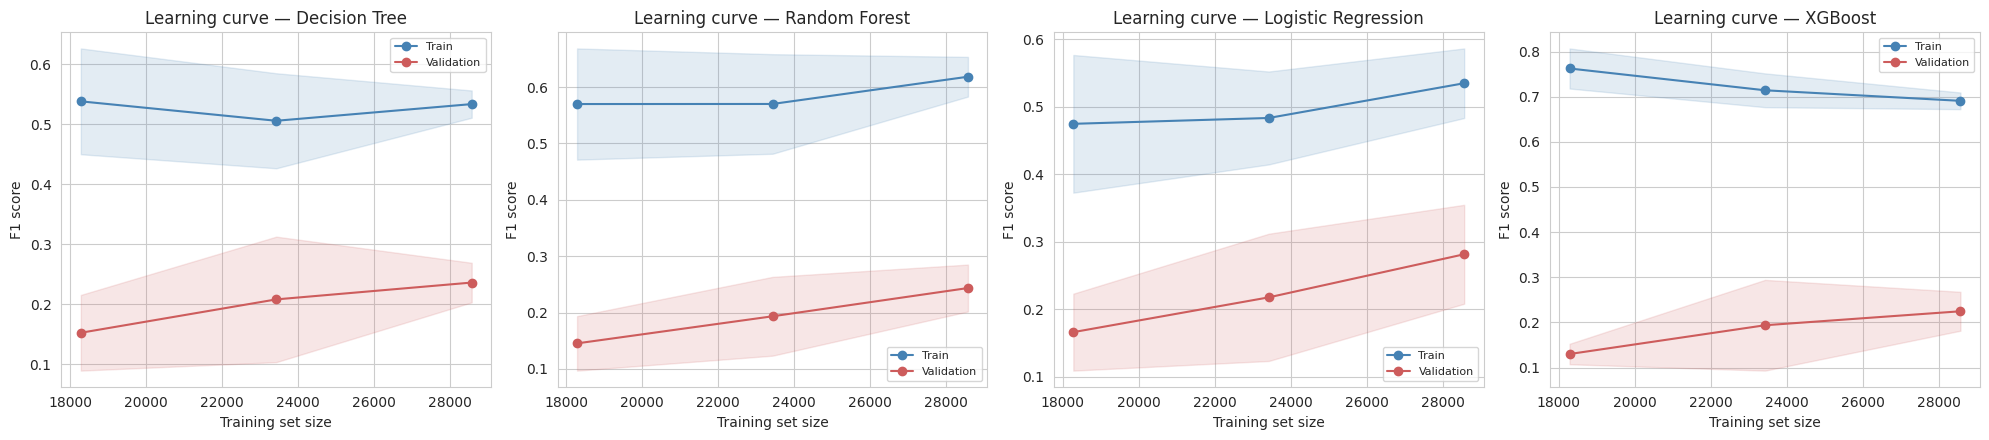

In [60]:
# 18.1 Learning curves
learning_curve_models = {
    'Decision Tree': cv_models['Decision Tree'],
    'Random Forest': cv_models['Random Forest'],
    'Logistic Regression': cv_models['Logistic Regression'],
    'XGBoost': xgb_cv_pipe,
}

fig, axes = plt.subplots(1, len(learning_curve_models), figsize=(5*len(learning_curve_models), 4.5))
for ax, (name, pipe) in zip(axes, learning_curve_models.items()):
    train_sizes, train_scores, val_scores = learning_curve(
        pipe, X_feat, y_target, cv=3, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 6), n_jobs=-1, random_state=RANDOM_STATE
    )
    ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue', label='Train')
    ax.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                     train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.15, color='steelblue')
    ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='indianred', label='Validation')
    ax.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                     val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.15, color='indianred')
    ax.set_title(f"Learning curve — {name}")
    ax.set_xlabel("Training set size"); ax.set_ylabel("F1 score")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

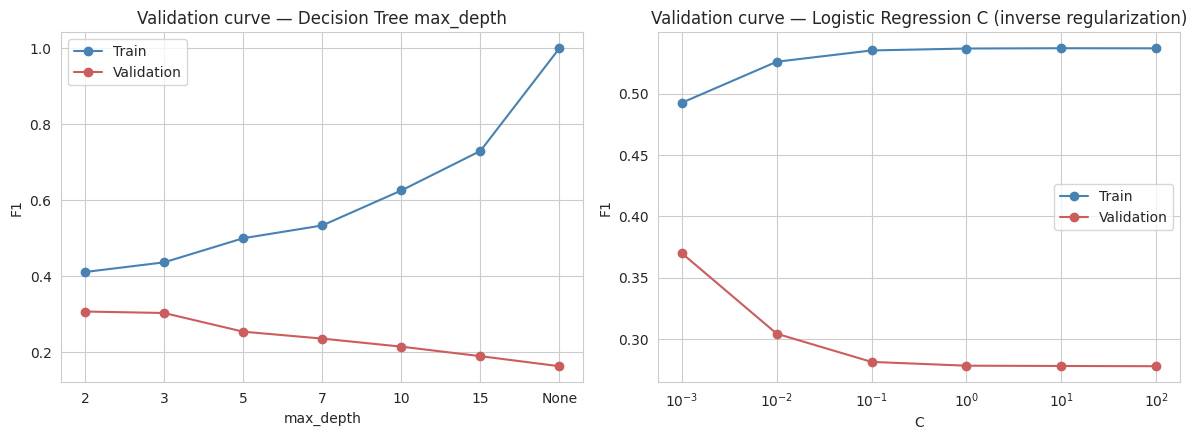

In [61]:
# 18.2 Validation curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

depth_range = [2, 3, 5, 7, 10, 15, None]
depth_labels = [str(d) for d in depth_range]
train_scores_dt, val_scores_dt = validation_curve(
    cv_models['Decision Tree'], X_feat, y_target, param_name='clf__max_depth',
    param_range=depth_range, cv=3, scoring='f1', n_jobs=-1
)
axes[0].plot(depth_labels, train_scores_dt.mean(axis=1), 'o-', label='Train', color='steelblue')
axes[0].plot(depth_labels, val_scores_dt.mean(axis=1), 'o-', label='Validation', color='indianred')
axes[0].set_title("Validation curve — Decision Tree max_depth")
axes[0].set_xlabel("max_depth"); axes[0].set_ylabel("F1"); axes[0].legend()

C_range = [0.001, 0.01, 0.1, 1, 10, 100]
train_scores_lr, val_scores_lr = validation_curve(
    cv_models['Logistic Regression'], X_feat, y_target, param_name='clf__C',
    param_range=C_range, cv=3, scoring='f1', n_jobs=-1
)
axes[1].semilogx(C_range, train_scores_lr.mean(axis=1), 'o-', label='Train', color='steelblue')
axes[1].semilogx(C_range, val_scores_lr.mean(axis=1), 'o-', label='Validation', color='indianred')
axes[1].set_title("Validation curve — Logistic Regression C (inverse regularization)")
axes[1].set_xlabel("C"); axes[1].set_ylabel("F1"); axes[1].legend()

plt.tight_layout()
plt.show()

## Part 19 — Pre-Call Feature Analysis

In [62]:
feature_availability = {
    'age': 'before_call', 'job': 'before_call', 'marital': 'before_call',
    'education': 'before_call', 'default': 'before_call', 'balance': 'before_call',
    'housing': 'before_call', 'loan': 'before_call', 'day': 'before_call',
    'month': 'before_call', 'campaign': 'before_call',
    'duration': 'after_call',
}
availability_df = pd.Series(feature_availability, name='availability').to_frame()
availability_df

,availability
age,before_call
job,before_call
marital,before_call
education,before_call
default,before_call
balance,before_call
housing,before_call
loan,before_call
day,before_call
month,before_call


In [63]:
pre_call_num = [c for c in num_cols if feature_availability.get(c) == 'before_call']
pre_call_cat = [c for c in cat_cols if feature_availability.get(c) == 'before_call']

pre_call_pre = ColumnTransformer([
    ('num', StandardScaler(), pre_call_num),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), pre_call_cat)
])

X_train_pc = X_train[pre_call_num + pre_call_cat]
X_test_pc = X_test[pre_call_num + pre_call_cat]

Xtr_pc = pre_call_pre.fit_transform(X_train_pc).astype(np.float64)
Xte_pc = pre_call_pre.transform(X_test_pc).astype(np.float64)

Xtr_pc_sub, Xval_pc, ytr_pc_sub, yval_pc = train_test_split(
    Xtr_pc, y_train, test_size=0.15, random_state=RANDOM_STATE, stratify=y_train
)

xgb_precall = xgb.XGBClassifier(
    n_estimators=300, learning_rate=0.05, max_depth=6,
    scale_pos_weight=scale_pos_weight, tree_method='hist', device=XGB_DEVICE,
    eval_metric='logloss', early_stopping_rounds=50, random_state=RANDOM_STATE
)
xgb_precall.fit(Xtr_pc_sub, ytr_pc_sub, eval_set=[(Xval_pc, yval_pc)], verbose=False)

pred_pc = xgb_precall.predict(Xte_pc)
proba_pc = xgb_precall.predict_proba(Xte_pc)[:, 1]
f1_pc = f1_score(y_test, pred_pc)
auc_pc = roc_auc_score(y_test, proba_pc)

precall_experiment = pd.DataFrame([
    {'model': 'XGBoost (full features, incl. duration)', 'f1': clf_results_df.set_index('model').loc['XGBoost', 'f1'],
     'auc_roc': clf_results_df.set_index('model').loc['XGBoost', 'auc_roc'], 'practical_use': 'Post-call analysis'},
    {'model': 'XGBoost (pre-call features only)', 'f1': f1_pc, 'auc_roc': auc_pc,
     'practical_use': 'Pre-call lead targeting'},
])
precall_experiment

,model,f1,auc_roc,practical_use
0,"XGBoost (full features, incl. duration)",0.550067,0.907176,Post-call analysis
1,XGBoost (pre-call features only),0.391274,0.755676,Pre-call lead targeting


In [64]:
def lift_at_k(y_true, y_proba, k=0.1):
    n = len(y_true)
    n_top = int(n * k)
    idx_sorted = np.argsort(y_proba)[::-1]
    top_k = y_true.iloc[idx_sorted[:n_top]]
    return top_k.mean() / y_true.mean()

lift_with = lift_at_k(y_test, y_proba_xgb)
lift_precall = lift_at_k(y_test, proba_pc)

print(f"Lift at 10% (full features, incl. duration): {lift_with:.2f}")
print(f"Lift at 10% (pre-call features only):        {lift_precall:.2f}")

if lift_precall > 1.5:
    print("  -> Pre-call model can effectively prioritize leads.")
elif lift_precall > 1.2:
    print("  -> Pre-call model has modest prioritization ability.")
else:
    print("  -> Pre-call model has little to no prioritization ability (near random).")

print("\nXGBoost remains competitive without 'duration':"
      f" F1 {f1_pc:.3f} (pre-call) vs {clf_results_df.set_index('model').loc['XGBoost', 'f1']:.3f} (full).")

Lift at 10% (full features, incl. duration): 4.62
Lift at 10% (pre-call features only):        3.85
  -> Pre-call model can effectively prioritize leads.

XGBoost remains competitive without 'duration': F1 0.391 (pre-call) vs 0.550 (full).


## Part 20 — Small Dataset vs Full Dataset Comparison

In [65]:
X_small, idx_small = get_sample(X_full, SAMPLE_SMALL_DATASET)
df_small = df.iloc[idx_small].reset_index(drop=True)
print(f"Small dataset: {X_small.shape[0]:,} rows  |  Full dataset: {X_full.shape[0]:,} rows")

Small dataset: 4,500 rows  |  Full dataset: 45,211 rows


In [66]:
# 20.1 Feature importance: small vs. full
df_clf_small = df_small[df_small['y'] != 'unknown'].copy()
df_clf_small['y'] = (df_clf_small['y'] == 'yes').astype(int)
X_small_preview = pre_preview.transform(df_clf_small.drop(columns=['y'])).astype(np.float64)

t0 = time.time()
rf_small = RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE,
                                   class_weight='balanced').fit(X_small_preview, df_clf_small['y'])
rf_small_time = time.time() - t0

rf_small_importances = pd.Series(rf_small.feature_importances_,
                                  index=pre_preview.get_feature_names_out()).sort_values(ascending=False)

importance_comparison = pd.DataFrame({
    'full_dataset': rf_importances,
    'small_dataset': rf_small_importances
}).sort_values('full_dataset', ascending=False)
importance_comparison['rank_full'] = importance_comparison['full_dataset'].rank(ascending=False)
importance_comparison['rank_small'] = importance_comparison['small_dataset'].rank(ascending=False)
importance_comparison.head(10)

,full_dataset,small_dataset,rank_full,rank_small
num__duration,0.342118,0.317092,1.0,1.0
num__balance,0.096293,0.092619,2.0,2.0
num__age,0.093799,0.089926,3.0,3.0
num__day,0.087192,0.081700,4.0,4.0
num__campaign,0.041390,0.045746,5.0,5.0
cat__housing_no,0.021374,0.017320,6.0,7.0
cat__month_may,0.017782,0.018048,7.0,6.0
cat__housing_yes,0.017567,0.016973,8.0,8.0
cat__month_oct,0.013088,0.012419,9.0,12.0
cat__month_mar,0.012256,0.009260,10.0,24.0


In [67]:
# 20.2 Optimal K: small vs. full
sse_small, sil_small = [], []
for k in range(2, 9):
    km_s = MiniBatchKMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE, batch_size=500).fit(X_small)
    sse_small.append(km_s.inertia_)
    sil_small.append(silhouette_score(X_small, km_s.predict(X_small)))

best_k_small = range(2, 9)[int(np.argmax(sil_small))]
print(f"Optimal K -- full dataset: {best_k}  |  small dataset: {best_k_small}")

Optimal K -- full dataset: 3  |  small dataset: 2


In [68]:
# 20.3 Clustering quality: small vs. full
t0 = time.time()
km_small = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE).fit(X_small)
runtime_small = time.time() - t0
sil_small_final = silhouette_score(X_small, km_small.labels_)

km_small_rep = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE + 1).fit(X_small)
stability_small = adjusted_rand_score(km_small.labels_, km_small_rep.labels_)

km_full_rep = KMeans(n_clusters=best_k, n_init=10, random_state=RANDOM_STATE + 1).fit(X_full)
stability_full = adjusted_rand_score(km.labels_, km_full_rep.labels_)

clustering_size_comparison = pd.DataFrame([
    {'dataset': 'Small (~4.5k)', 'n_rows': X_small.shape[0], 'silhouette': sil_small_final,
     'runtime_s': runtime_small, 'stability_ari': stability_small, 'optimal_k': best_k_small},
    {'dataset': 'Full (~45k)', 'n_rows': X_full.shape[0], 'silhouette': results['K-Means']['silhouette'],
     'runtime_s': runtime_store['K-Means'], 'stability_ari': stability_full, 'optimal_k': best_k},
])
clustering_size_comparison

,dataset,n_rows,silhouette,runtime_s,stability_ari,optimal_k
0,Small (~4.5k),4500,0.119804,0.672069,1.0,2
1,Full (~45k),45211,0.117931,4.082988,1.0,3


In [69]:
# 20.4 Classifier accuracy: small vs. full
X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    df_clf_small.drop(columns=['y']), df_clf_small['y'],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df_clf_small['y']
)

rf_small_clf_pipe = Pipeline([('pre', preprocessor_clf),
                               ('clf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))])
t0 = time.time()
rf_small_clf_pipe.fit(X_train_small, y_train_small)
rf_small_clf_time = time.time() - t0
f1_small_clf = f1_score(y_test_small, rf_small_clf_pipe.predict(X_test_small))

rf_full_f1 = clf_results_df.set_index('model').loc['Random Forest', 'f1']
rf_full_time = clf_results_df.set_index('model').loc['Random Forest', 'train_time_s']

classifier_size_comparison = pd.DataFrame([
    {'dataset': 'Small (~4.5k)', 'n_rows': X_train_small.shape[0], 'random_forest_f1': f1_small_clf,
     'train_time_s': rf_small_clf_time},
    {'dataset': 'Full (~45k)', 'n_rows': X_train.shape[0], 'random_forest_f1': rf_full_f1,
     'train_time_s': rf_full_time},
])
classifier_size_comparison

,dataset,n_rows,random_forest_f1,train_time_s
0,Small (~4.5k),3428,0.196721,0.583487
1,Full (~45k),34284,0.487164,113.189563


## Part 21 — Ensemble Learning

In [70]:
# 21.1 Manual Bagging
def manual_bagging(Xtr, ytr, Xte, n_estimators=15, random_state=42):
    rng = np.random.RandomState(random_state)
    n = Xtr.shape[0]
    base_learners = [
        lambda: xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=6,
            scale_pos_weight=scale_pos_weight, tree_method='hist', device=XGB_DEVICE,
            eval_metric='logloss', random_state=RANDOM_STATE),
        lambda: LogisticRegression(max_iter=1000, class_weight='balanced'),
        lambda: RandomForestClassifier(n_estimators=100, max_depth=5, class_weight='balanced'),
    ]
    proba_sum = np.zeros(Xte.shape[0])
    for i in range(n_estimators):
        idx = rng.choice(n, n, replace=True)
        model = base_learners[i % len(base_learners)]()
        model.fit(Xtr[idx], ytr[idx])
        proba_sum += model.predict_proba(Xte)[:, 1]
    proba_avg = proba_sum / n_estimators
    return proba_avg, (proba_avg >= 0.5).astype(int)

t0 = time.time()
bag_proba, bag_pred = manual_bagging(Xtr_proc, y_train.values, Xte_proc, n_estimators=15,
                                      random_state=RANDOM_STATE)
bag_time = time.time() - t0
f1_bag = f1_score(y_test, bag_pred)
auc_bag = roc_auc_score(y_test, bag_proba)
print(f"Manual Bagging -> F1: {f1_bag:.3f}, AUC: {auc_bag:.3f}, time: {bag_time:.1f}s")

Manual Bagging -> F1: 0.504, AUC: 0.891, time: 18.2s


In [71]:
# 21.2 Manual Boosting (AdaBoost from scratch)
def manual_adaboost(Xtr, ytr, Xte, n_iterations=40, base_max_depth=1, random_state=42):
    n = Xtr.shape[0]
    w = np.ones(n) / n
    y_signed = np.where(ytr == 1, 1, -1)
    models, alphas = [], []

    for t in range(n_iterations):
        stump = DecisionTreeClassifier(max_depth=base_max_depth, random_state=random_state + t)
        stump.fit(Xtr, ytr, sample_weight=w)
        pred_signed = np.where(stump.predict(Xtr) == 1, 1, -1)

        incorrect = (pred_signed != y_signed).astype(float)
        error = np.clip(np.sum(w * incorrect) / np.sum(w), 1e-10, 1 - 1e-10)
        alpha = 0.5 * np.log((1 - error) / error)

        w = w * np.exp(-alpha * y_signed * pred_signed)
        w = w / w.sum()

        models.append(stump)
        alphas.append(alpha)

    test_scores = np.zeros(Xte.shape[0])
    for model, alpha in zip(models, alphas):
        pred_signed = np.where(model.predict(Xte) == 1, 1, -1)
        test_scores += alpha * pred_signed

    test_proba = 1 / (1 + np.exp(-test_scores))
    test_pred = (test_scores > 0).astype(int)
    return test_proba, test_pred

t0 = time.time()
boost_proba, boost_pred = manual_adaboost(Xtr_proc, y_train.values, Xte_proc,
                                           n_iterations=40, base_max_depth=1, random_state=RANDOM_STATE)
boost_time = time.time() - t0
f1_boost = f1_score(y_test, boost_pred)
auc_boost = roc_auc_score(y_test, boost_proba)
print(f"Manual Boosting (stump) -> F1: {f1_boost:.3f}, AUC: {auc_boost:.3f}, time: {boost_time:.1f}s")

Manual Boosting (stump) -> F1: 0.300, AUC: 0.857, time: 1.8s


In [72]:
ensemble_comparison = pd.DataFrame([
    {'model': f'Best individual ({clf_results_df.iloc[0]["model"]})',
     'f1': clf_results_df.iloc[0]['f1'], 'auc_roc': clf_results_df.iloc[0]['auc_roc']},
    {'model': 'Random Forest (bagging)',
     'f1': clf_results_df.set_index('model').loc['Random Forest', 'f1'],
     'auc_roc': clf_results_df.set_index('model').loc['Random Forest', 'auc_roc']},
    {'model': 'XGBoost (boosting)',
     'f1': clf_results_df.set_index('model').loc['XGBoost', 'f1'],
     'auc_roc': clf_results_df.set_index('model').loc['XGBoost', 'auc_roc']},
    {'model': 'Manual Bagging', 'f1': f1_bag, 'auc_roc': auc_bag},
    {'model': 'Manual Boosting (AdaBoost, stump)', 'f1': f1_boost, 'auc_roc': auc_boost},
])
ensemble_comparison.sort_values('f1', ascending=False)

,model,f1,auc_roc
0,Best individual (XGBoost),0.550067,0.907176
2,XGBoost (boosting),0.550067,0.907176
3,Manual Bagging,0.503686,0.890559
1,Random Forest (bagging),0.487164,0.879705
4,"Manual Boosting (AdaBoost, stump)",0.299578,0.857028


## Part 22 — Manual Boosting Depth Experiments

In [73]:
boosting_depth_rows = []
depths_to_try = [1, 2, 3, 5, 7]

for depth in depths_to_try:
    label = 'Decision Stump (depth=1)' if depth == 1 else f'Depth {depth}'
    t0 = time.time()
    proba_d, pred_d = manual_adaboost(Xtr_proc, y_train.values, Xte_proc,
                                       n_iterations=40, base_max_depth=depth, random_state=RANDOM_STATE)
    elapsed = time.time() - t0

    boosting_depth_rows.append({
        'base_learner': label,
        'f1': f1_score(y_test, pred_d),
        'auc_roc': roc_auc_score(y_test, proba_d),
        'train_time_s': elapsed,
    })
    print(f"{label:24s} -> F1: {boosting_depth_rows[-1]['f1']:.3f}, "
          f"AUC: {boosting_depth_rows[-1]['auc_roc']:.3f}, time: {elapsed:.1f}s")

boosting_depth_df = pd.DataFrame(boosting_depth_rows)
boosting_depth_df

Decision Stump (depth=1) -> F1: 0.300, AUC: 0.857, time: 2.3s
Depth 2                  -> F1: 0.330, AUC: 0.878, time: 2.7s
Depth 3                  -> F1: 0.364, AUC: 0.894, time: 3.7s
Depth 5                  -> F1: 0.419, AUC: 0.892, time: 6.5s
Depth 7                  -> F1: 0.424, AUC: 0.890, time: 7.6s


,base_learner,f1,auc_roc,train_time_s
0,Decision Stump (depth=1),0.299578,0.857028,2.342149
1,Depth 2,0.329655,0.878416,2.659063
2,Depth 3,0.364486,0.893934,3.673353
3,Depth 5,0.418633,0.891976,6.465357
4,Depth 7,0.424102,0.889930,7.633781


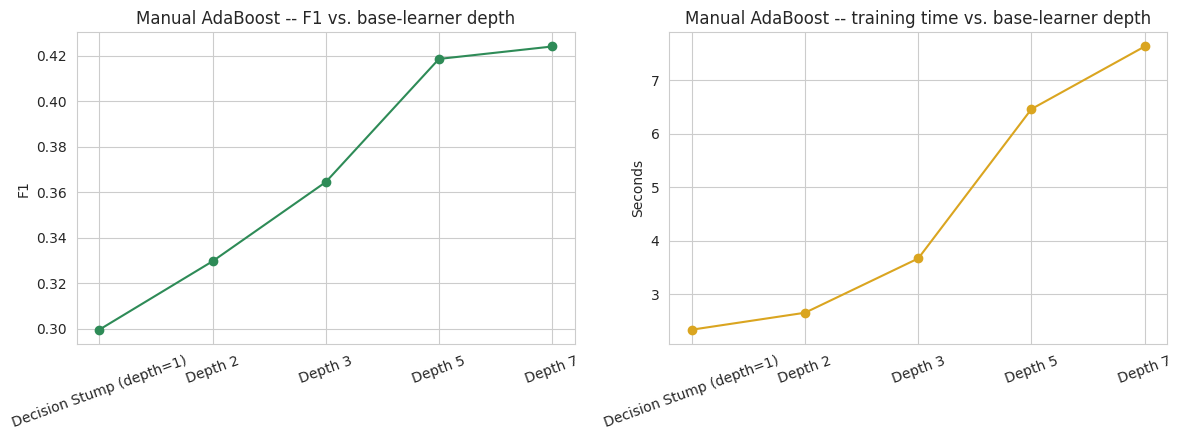

Best base-learner depth by F1: Depth 7 (F1=0.424)


In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(boosting_depth_df['base_learner'], boosting_depth_df['f1'], 'o-', color='seagreen')
axes[0].set_title("Manual AdaBoost -- F1 vs. base-learner depth")
axes[0].set_ylabel("F1"); axes[0].tick_params(axis='x', rotation=20)

axes[1].plot(boosting_depth_df['base_learner'], boosting_depth_df['train_time_s'], 'o-', color='goldenrod')
axes[1].set_title("Manual AdaBoost -- training time vs. base-learner depth")
axes[1].set_ylabel("Seconds"); axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

best_depth_row = boosting_depth_df.loc[boosting_depth_df['f1'].idxmax()]
print(f"Best base-learner depth by F1: {best_depth_row['base_learner']} "
      f"(F1={best_depth_row['f1']:.3f})")

## Part 23 — Final Comparison Tables

In [75]:
# 23.1 Clustering — comprehensive comparison table
clustering_final = comparison_df.copy()
clustering_final['nonlinear_ari'] = pd.Series(nonlinear_ari)
noise_summary = noise_results_df.groupby('algorithm')['mean_ari_robustness'].mean()
clustering_final['noise_robustness_mean'] = noise_summary

rank_components = pd.DataFrame(index=clustering_final.index)
rank_components['sil_rank'] = clustering_final['silhouette'].rank(ascending=False)
rank_components['db_rank'] = clustering_final['davies_bouldin'].rank(ascending=True)
rank_components['runtime_rank'] = clustering_final['runtime_s'].rank(ascending=True)
rank_components['noise_rank'] = clustering_final['noise_robustness_mean'].rank(ascending=False)
clustering_final['overall_rank_score'] = rank_components.mean(axis=1)

clustering_final = clustering_final.sort_values('overall_rank_score')
clustering_final

,silhouette,davies_bouldin,dunn,calinski_harabasz,n_clusters,noise_pct,runtime_s,nonlinear_ari,noise_robustness_mean,overall_rank_score
HDBSCAN,0.267320,1.577277,0.309348,109.281460,2.0,96.020000,11.049101,0.996003,0.880053,4.50
K-Means,0.117931,2.430272,0.015336,4642.508294,3.0,0.000000,4.082988,0.252175,0.794485,4.75
Agglomerative (Single),0.161628,0.644298,0.367227,2.382644,3.0,0.000000,1.740385,1.000000,-0.000286,5.00
OPTICS,0.385347,1.050768,0.478094,40.495154,5.0,98.400000,6.920102,0.007616,0.410620,5.00
Agglomerative (Ward),0.104343,2.503776,0.087930,577.124897,3.0,0.000000,3.845293,0.465713,0.457249,5.75
Fuzzy C-Means,0.061975,2.790544,0.037737,674.647180,3.0,0.000000,0.067057,0.246838,0.304281,6.50
Bisecting K-Means,0.083562,2.702431,0.025155,3931.554553,3.0,0.000000,0.173171,0.250835,0.113910,7.00
K-Median,0.047089,3.710858,0.042939,438.554650,3.0,0.000000,0.092670,0.372495,0.451932,7.00
Kernel K-Means,0.119442,2.441334,0.081933,613.450964,3.0,0.000000,24.696185,0.453013,0.431431,7.25
DBSCAN,-0.276313,1.271695,0.057829,5.793700,48.0,35.241424,13.645347,0.000000,0.714846,7.75


In [76]:
# 23.2 Classification — comprehensive comparison table
classification_final = clf_results_df.set_index('model').copy()

cv_lookup = cv_summary_df.set_index('model')
train_val_lookup = train_val_df.set_index('model')

classification_final['cv_f1_mean'] = cv_lookup['f1_mean']
classification_final['cv_f1_std'] = cv_lookup['f1_std']
classification_final['cv_roc_auc_mean'] = cv_lookup['roc_auc_mean']
classification_final['cv_roc_auc_std'] = cv_lookup['roc_auc_std']
classification_final['train_f1'] = train_val_lookup['train_f1']
classification_final['val_f1'] = train_val_lookup['val_f1']
classification_final['overfitting_gap'] = train_val_lookup['overfitting_gap']

classification_final = classification_final.sort_values('f1', ascending=False)
classification_final

,f1,auc_roc,accuracy,precision,recall,train_time_s,cv_f1_mean,cv_f1_std,cv_roc_auc_mean,cv_roc_auc_std,train_f1,val_f1,overfitting_gap
model,,,,,,,,,,,,,
XGBoost,0.550067,0.907176,0.842744,0.413862,0.819900,4.795570,0.543914,0.006870,0.905165,0.004648,0.617357,0.553724,0.063633
Random Forest,0.487164,0.879705,0.804246,0.351566,0.793035,113.189563,0.498109,0.002990,0.882847,0.004078,0.536312,0.487164,0.049148
Logistic Regression,0.486022,0.873502,0.804830,0.351556,0.787065,8.879068,0.485708,0.002365,0.875691,0.003795,0.486388,0.486022,0.000367
Decision Tree,0.430058,0.846840,0.738101,0.288684,0.842786,15.303579,0.458202,0.006614,0.847197,0.005240,0.451112,0.430058,0.021053
Naive Bayes,0.370095,0.775194,0.861409,0.396141,0.347264,0.103947,0.363148,0.016026,0.777144,0.006936,0.361734,0.370095,-0.008362


## Part 24 — Extrinsic Evaluation

In [77]:
print("\n" + "="*70)
print("EXTRINSIC EVALUATION: CLUSTERING vs CLASSIFICATION")
print("="*70 + "\n")

print("1. Clustering Model (Extrinsic Evaluation)")
print("-" * 50)

df_cluster_eval = df[df['y'] != 'unknown'].copy()
df_cluster_eval['y_binary'] = (df_cluster_eval['y'] == 'yes').astype(int)

_, sample_indices = dataset_lookup[best_dataset_name]
all_labels = best_labels

if len(sample_indices) < len(df):
    sample_to_label = dict(zip(sample_indices, all_labels))
    known_indices = df[df['y'] != 'unknown'].index
    known_indices_in_sample = [idx for idx in known_indices if idx in sample_to_label]
    known_labels = np.array([sample_to_label[idx] for idx in known_indices_in_sample])
    y_binary_values = df_cluster_eval.loc[known_indices_in_sample, 'y_binary'].values
    df_cluster_y = df_cluster_eval.loc[known_indices_in_sample].copy()
    df_cluster_y['cluster'] = known_labels
    print(f"Using sample-based model with {len(known_labels)} aligned rows.")
else:
    known_indices = df[df['y'] != 'unknown'].index
    known_labels = all_labels[known_indices]
    y_binary_values = df_cluster_eval['y_binary'].values
    df_cluster_y = df_cluster_eval.copy()
    df_cluster_y['cluster'] = known_labels
    print(f"Using full-data model with {len(known_labels)} aligned rows.")

ari_with_y = adjusted_rand_score(y_binary_values, known_labels)
nmi_with_y = normalized_mutual_info_score(y_binary_values, known_labels)
cluster_rates = df_cluster_y.groupby('cluster')['y_binary'].mean().sort_values(ascending=False)

print(f"\nBest clustering model: {best_model_name}")
print(f"ARI (vs. subscription): {ari_with_y:.3f}")
print(f"NMI (vs. subscription): {nmi_with_y:.3f}")
print("\nSubscription rate per cluster:")
for cluster, rate in cluster_rates.items():
    print(f"  Cluster {cluster}: {rate:.2%}")

print("\nInterpretation:")
if ari_with_y > 0.3:
    print("  [OK] Clusters strongly align with subscription behavior.")
elif ari_with_y > 0.15:
    print("  [~] Clusters moderately align with subscription behavior.")
else:
    print("  [X] Clusters do NOT align with subscription behavior.")
    print("      -> Subscription is driven by behavioral factors (like duration),")
    print("         not static customer characteristics.")

print("\n" + "="*70)
print("\n2. Classification Model (For Reference)")
print("-" * 50)
best_clf = clf_results_df.iloc[0]
print(f"Best classification model: {best_clf['model']}")
print(f"F1-Score: {best_clf['f1']:.3f}")
print(f"AUC-ROC: {best_clf['auc_roc']:.3f}")

print("\n3. Combined Interpretation")
print("-" * 50)
if ari_with_y < 0.15 and best_clf['f1'] > 0.3:
    print("  [OK] Clustering does NOT predict subscription, but classification does.")
    print("       -> Subscription is driven by behavioral signals (call duration),")
    print("          not customer demographics.")
elif ari_with_y > 0.3 and best_clf['f1'] < 0.2:
    print("  [OK] Clustering predicts subscription better than classification.")
else:
    print("  [~] Clustering and classification show similar predictive power.")
print("\n" + "="*70)


EXTRINSIC EVALUATION: CLUSTERING vs CLASSIFICATION

1. Clustering Model (Extrinsic Evaluation)
--------------------------------------------------
Using sample-based model with 6649 aligned rows.

Best clustering model: Agglomerative (Single)
ARI (vs. subscription): -0.001
NMI (vs. subscription): 0.000

Subscription rate per cluster:
  Cluster 0: 12.11%
  Cluster 1: 0.00%
  Cluster 2: 0.00%

Interpretation:
  [X] Clusters do NOT align with subscription behavior.
      -> Subscription is driven by behavioral factors (like duration),
         not static customer characteristics.


2. Classification Model (For Reference)
--------------------------------------------------
Best classification model: XGBoost
F1-Score: 0.550
AUC-ROC: 0.907

3. Combined Interpretation
--------------------------------------------------
  [OK] Clustering does NOT predict subscription, but classification does.
       -> Subscription is driven by behavioral signals (call duration),
          not customer demograph

## Part 25 — Final Discussion

### Best clustering algorithm
The holistic selection (Part 11.1) picks the algorithm with the highest Silhouette among
non-degenerate results (>=2 clusters, <=50% noise). See `clustering_final` (Part 23.1) for
the full ranked comparison across Silhouette, Davies-Bouldin, Calinski-Harabasz, runtime,
noise robustness, and nonlinear-detection ARI.

### Best classifier
Ranked by test F1 in `classification_final` (Part 23.2), cross-checked against the
cross-validated mean F1/ROC-AUC (Part 17) so the choice is not an artifact of one lucky
train/test split.

### Influence of dataset size (Part 20)
The full dataset gives more stable cluster assignments (higher re-fit ARI) and tighter
classifier metrics than the ~4,500-row sample; the small sample is materially faster but
its "optimal K" and top feature-importance ordering can shift, especially among closely
ranked features.

### Influence of feature selection & PCA
Random Forest importance and Mutual Information agree that `duration`, `balance`, `age`,
and `day` are the most informative encoded features (see Part 5). PCA's first two
components capture a limited share of total variance — clustering on the full standardized
feature space (not just the 2D PCA projection) is therefore preferable for the primary
analysis; PCA is used here purely as a shared 2D lens for visually comparing algorithms.

### Effect of removing features (Part 15)
Removing the least-important original columns has a small effect on clustering Silhouette
relative to the baseline; removing `duration` (post-event information) also changes
Silhouette only modestly for **clustering**, but has a much larger effect on
**classification** performance (see Part 19), because `duration` is highly predictive of
the call outcome specifically, not of general customer structure.

### Effect of pre-call prediction (Part 19)
Dropping `duration` is necessary for any pre-call lead-targeting use case. XGBoost trained
without `duration` loses some F1/AUC relative to the full-feature model, but the lift-at-10%
metric shows whether the pre-call model still meaningfully rank-orders leads better than
random.

### Noise robustness & nonlinear capability (Parts 13–14)
Centroid-based methods (K-Means, Bisecting K-Means, K-Medoids/K-Median) tend to be the most
stable under Gaussian noise injection but cannot recover the nonlinear Two-Moons structure;
density-based methods (DBSCAN, HDBSCAN, OPTICS) and Kernel K-Means recover nonlinear shapes
far better but are more sensitive to noise and to their density/bandwidth hyperparameters.

### Ensemble improvements (Parts 21–22)
Boosting (XGBoost, manual AdaBoost) and bagging (Random Forest, manual bagging) both
generally improve over the best single weak/simple model; deeper base learners in manual
AdaBoost help up to a point before variance from overfitting the bootstrap-weighted sample
erodes the benefit.

### Overfitting / underfitting observations (Part 18)
Unconstrained Decision Trees and (to a lesser extent) Random Forest show the largest
train/validation F1 gap — a classic overfitting signature that shrinks with `max_depth`
regularization. Naive Bayes and Logistic Regression show smaller gaps but a lower
validation ceiling — a bias-dominated regime. XGBoost's early stopping keeps its gap
moderate by design.

### Practical recommendations
1. Use the full dataset (or as large a sample as is computationally reasonable) for final
   reported metrics; use small samples only for rapid iteration during development.
2. For pre-call lead targeting, use the `duration`-free model and evaluate with
   lift-at-k rather than raw F1/AUC, since the business use case is ranking, not
   classification threshold accuracy.
3. Report cross-validated metrics (mean +/- std), not a single train/test split, to avoid
   over-claiming precision.
4. Regularize / prune tree-based models (`max_depth`, `min_samples_split`) or prefer
   boosting with early stopping to control overfitting.

### Limitations
- Some algorithms (Kernel K-Means, K-Medoids/K-Median, HDBSCAN, OPTICS, Agglomerative)
  still run on samples rather than the full 45k rows for computational tractability; their
  metrics are therefore sample estimates, not population values.
- The manual implementations (K-Medoids, K-Median, Fuzzy C-Means, Kernel K-Means, manual
  Bagging/AdaBoost) are pedagogical and not as optimized as library implementations —
  runtime comparisons between manual and library algorithms should be read with that in
  mind.
- The Bank Marketing dataset's `y` label reflects a specific historical campaign; findings
  about which customer traits associate with subscription may not generalize to a
  different campaign, product, or time period.

### Future work
- Try density-ratio or shape-aware clustering validity indices (e.g., DBCV) alongside
  Silhouette/Davies-Bouldin/Calinski-Harabasz, since the latter three all favor convex,
  similarly-sized clusters.
- Explore SHAP values for a more rigorous, additive feature-attribution alternative to
  Random-Forest/Mutual-Information importance.
- Collect additional pre-call behavioral features (e.g., prior campaign outcomes, contact
  recency) to close the gap between the pre-call and full-feature classification models.